IMPORTACIONES Y CARGA DE DATOS
--------

In [242]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

import holidays

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   # u otros scalers
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import KNNImputer #agregado
from sklearn.pipeline import Pipeline #agregado
from sklearn.model_selection import KFold, cross_val_score #agregado
from sklearn.pipeline import make_pipeline #agregado
from sklearn.compose import ColumnTransformer #agregado

In [243]:
### carga datos de dataset en dataframe
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

In [244]:
### visualizacion de algunos datos
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

In [245]:
### Columnas, ¿cuáles son variables numéricas y cuales variables categóricas?
df.columns

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')

EDA
--------


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


#### _Análisis sobre variables de coordenadas_

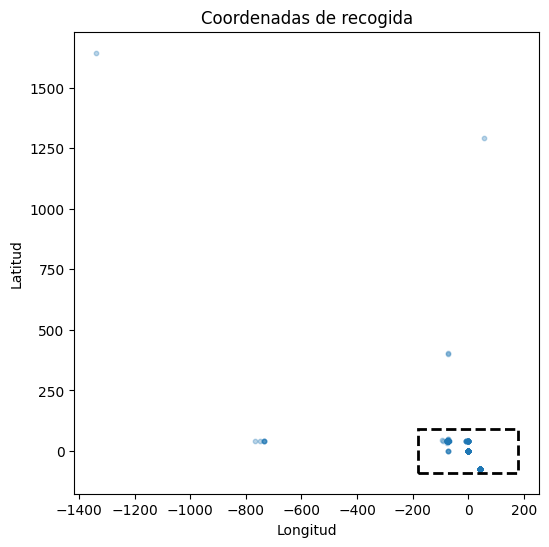

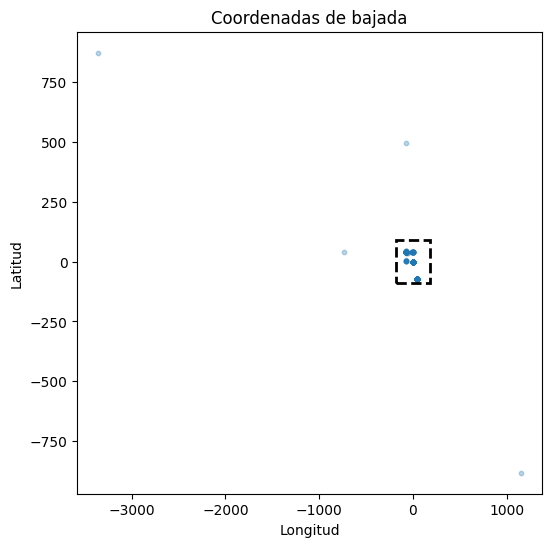

In [247]:
#Coordenadas de Pickup
plt.figure(figsize=(6,6))
plt.scatter(df["pickup_longitude"], df["pickup_latitude"], s=10, alpha=0.3)

#Rectángulo que representa las coordenadas validas del mundo
world_rect = patches.Rectangle(
    (-180, -90),  
    360,          
    180,           
    linewidth=2, edgecolor='black', facecolor='none', linestyle='--'
)
plt.gca().add_patch(world_rect)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Coordenadas de recogida")
plt.show()

#Coordenadas de Dropoff
plt.figure(figsize=(6,6))
plt.scatter(df["dropoff_longitude"], df["dropoff_latitude"], s=10, alpha=0.3)

#Rectángulo que representa las coordenadas validas del mundo
world_rect = patches.Rectangle(
    (-180, -90),  
    360,          
    180,           
    linewidth=2, edgecolor='black', facecolor='none', linestyle='--'
)
plt.gca().add_patch(world_rect)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Coordenadas de bajada")
plt.show()


In [248]:
#Coordenadas reales
lat_min, lat_max = -90, 90  
lon_min, lon_max = -180, 180

valid_pickup_lat = df["pickup_latitude"].between(lat_min, lat_max)
valid_pickup_lon = df["pickup_longitude"].between(lon_min, lon_max)
valid_dropoff_lat = df["dropoff_latitude"].between(lat_min, lat_max)
valid_dropoff_lon = df["dropoff_longitude"].between(lon_min, lon_max)

invalid_counts = (
    (~valid_pickup_lat).astype(int) +
    (~valid_pickup_lon).astype(int) +
    (~valid_dropoff_lat).astype(int) +
    (~valid_dropoff_lon).astype(int)
)

#Cantidad de registros con mas de 1 coordenada invalida que no es posible imputar
df_invalidos = df[invalid_counts > 1]
print('---Registros con más de 1 coordenada inválida---')
print(f'Cantidad: {df_invalidos.shape[0]}')
print(f'Porcentaje respecto al dataFrame completo: {(df_invalidos.shape[0]/df.shape[0])*100}%')

---Registros con más de 1 coordenada inválida---
Cantidad: 3
Porcentaje respecto al dataFrame completo: 0.0015%


Se decidió eliminar los registros con más de una coordenada inválida, ya que representaban apenas el 0,0015 % del conjunto de datos total. Al tratarse de un volumen despreciable, su eliminación no afecta la representatividad del dataset. Además, la magnitud del error (múltiples coordenadas simultáneamente inválidas) hacía inviable cualquier imputación, pues implicaría reconstruir información esencial sin una base confiable.

In [249]:
df_filtrado = df[invalid_counts <= 1]

In [250]:
#Reemplazamos las coordenadas inválidas con NaN para luego imputar
df_filtrado.loc[~valid_pickup_lat, "pickup_latitude"] = np.nan
df_filtrado.loc[~valid_pickup_lon, "pickup_longitude"] = np.nan
df_filtrado.loc[~valid_dropoff_lat, "dropoff_latitude"] = np.nan
df_filtrado.loc[~valid_dropoff_lon, "dropoff_longitude"] = np.nan

#Cantidad de registros reemplazados con NaN
print(f'Cantidad total de registros reemplazados con NaN: {df_filtrado.isna().sum().sum()}')
df_filtrado.isna().sum()

Cantidad total de registros reemplazados con NaN: 10


key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     6
pickup_latitude      2
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

#### _Análisis sobre fare_amount_

Cantidad de valores nulos en fare_amount: 0
Cantidad de valores cero y negativos en fare_amount: 22
Porcentaje de valores cero y negativos sobre el total de registros en fare_amount: 0.011000165002475037%


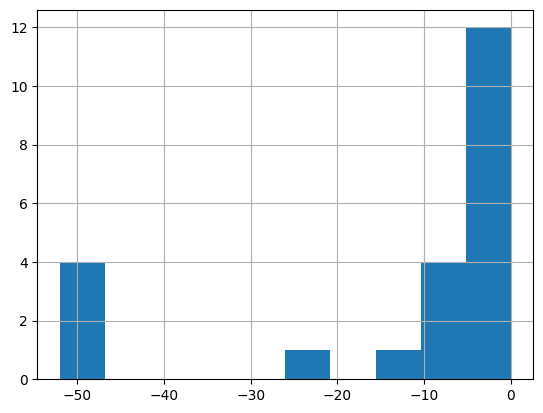

In [251]:
fare_amount_null = df_filtrado['fare_amount'].isnull().sum() 

print(f'Cantidad de valores nulos en fare_amount: {fare_amount_null}')

#Visualización de valores negativos y cero en fare_amount
df_filtrado[df_filtrado["fare_amount"] <= 0]["fare_amount"].hist()

negativos = df_filtrado[df_filtrado["fare_amount"] <= 0]['fare_amount'].size

print(f"Cantidad de valores cero y negativos en fare_amount: {negativos}")
print(f"Porcentaje de valores cero y negativos sobre el total de registros en fare_amount: {negativos / df_filtrado.fare_amount.size * 100}%") 

Se eliminaron los registros con valores de fare amount iguales a cero o negativos, dado que constituyen el variable objetivo del modelo y, en consecuencia, resultan inconsistentes con la lógica del problema. Una tarifa nula o negativa no tiene interpretación práctica en el contexto de viajes reales, por lo que mantener esos casos hubiera introducido ruido y sesgos en el entrenamiento.

In [252]:
df_filtrado = df_filtrado[df_filtrado['fare_amount'] > 0]  

#### _Función haversine_km para cálculo de distancias de cada viaje_

In [253]:
# Retorna distancia en kilómetros (vectorizado)
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

#Creamos la nueva columna 'distance_km' en el DataFrame en base a Haversine
df_filtrado['distance_km'] = haversine_km(
    df_filtrado['pickup_latitude'], df_filtrado['pickup_longitude'],
    df_filtrado['dropoff_latitude'], df_filtrado['dropoff_longitude']
)

Calculamos y creamos la columna "distancia_km" que es la diferencia entre las coordenadas de llegadas y salida, calculadas con Haversine ya que es una fórmula de trigonometría esférica que te da la distancia realista entre dos coordenadas geográficas en lugar de calcular la distancia euclideana. 
Condideramos que es más eficiente trabajar con este dato que con coordenadas "sueltas". 

In [254]:
df_filtrado['distance_km'].describe()

count    199965.000000
mean         20.475660
std         378.655684
min           0.000000
25%           1.215335
50%           2.120955
75%           3.874804
max        8782.898606
Name: distance_km, dtype: float64

<Axes: xlabel='distance_km'>

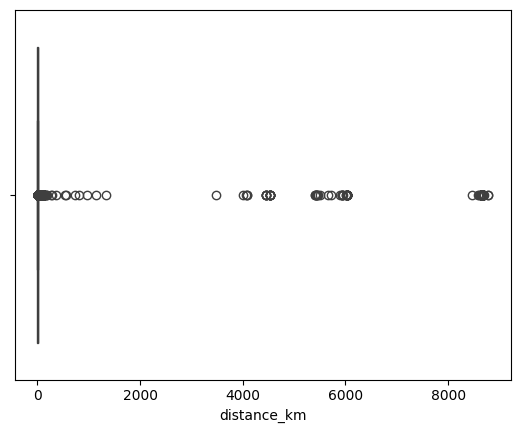

In [255]:
sns.boxplot(x=df_filtrado['distance_km'])

Graficamos el boxplot de esta nueva columna para analizar los outliers de distancias y decidir cómo tratar estos datos. 

#### _Análisis sobre variables de coordenadas para reducir distancias absurdas_

In [256]:
#Creamos máscaras con datos de coordenadas en NY y alrededores, inlcuyendo nulos aún no imputados. 
ny_coords = (
    (df_filtrado["pickup_latitude"].between(40, 42)| df_filtrado["pickup_latitude"].isna())&
    (df_filtrado["pickup_longitude"].between(-75, -72) | df_filtrado["pickup_longitude"].isna()) &
    (df_filtrado["dropoff_latitude"].between(40, 42) | df_filtrado["dropoff_latitude"].isna()) &
    (df_filtrado["dropoff_longitude"].between(-75, -72) | df_filtrado["dropoff_longitude"].isna())
)


df_filtrado_ny = df_filtrado[ny_coords].copy()

print(f'Cantidad de registros descartados por estar fuera de NY y alrededores: {df_filtrado[~ny_coords].shape[0]}')
print(f'Porcentaje de registros descartados por estar fuera de NY y alrededores: {(df_filtrado[~ny_coords].shape[0]/df_filtrado.shape[0])*100}%')


Cantidad de registros descartados por estar fuera de NY y alrededores: 4178
Porcentaje de registros descartados por estar fuera de NY y alrededores: 2.0892611576447053%


Decidimos eliminar los registros con coordenadas que no corresponden a la ciudad de Nueva York y/o alrededores, ya que consideramos que no forman parte del dominio real del estudio y representan valores atípicos que introducen ruido en los modelos.

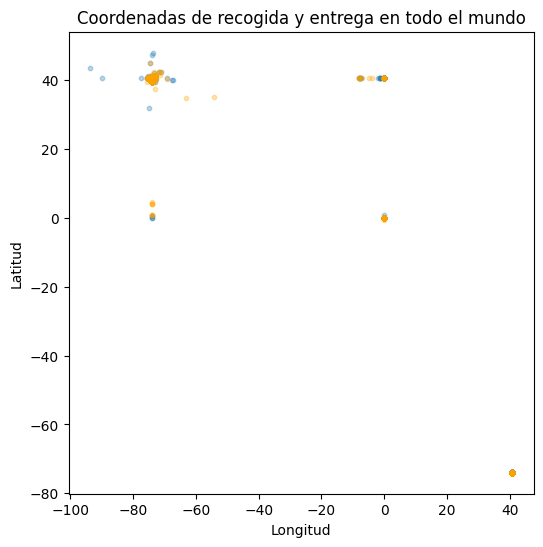

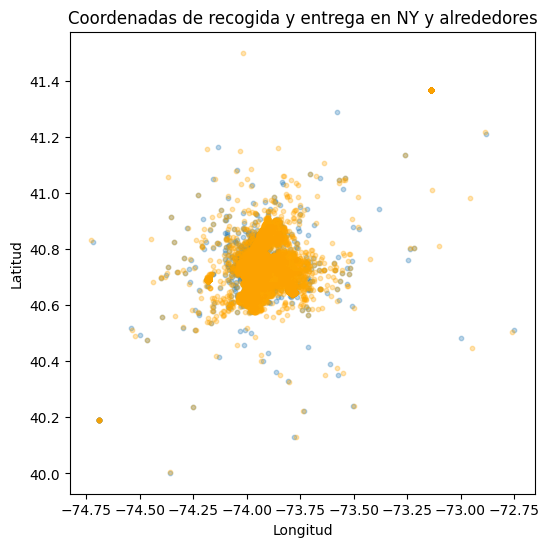

In [257]:
# Gráficos de coordenadas de recogida y entrega

plt.figure(figsize=(6,6))
plt.scatter(df_filtrado["pickup_longitude"], df_filtrado["pickup_latitude"], s=10, alpha=0.3)
plt.scatter(df_filtrado["dropoff_longitude"], df_filtrado["dropoff_latitude"], s=10, alpha=0.3, color='orange')
plt.xlabel("Longitud")          
plt.ylabel("Latitud")
plt.title("Coordenadas de recogida y entrega en todo el mundo")      
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(df_filtrado_ny["pickup_longitude"], df_filtrado_ny["pickup_latitude"], s=10, alpha=0.3)
plt.scatter(df_filtrado_ny["dropoff_longitude"], df_filtrado_ny["dropoff_latitude"], s=10, alpha=0.3, color='orange')
plt.xlabel("Longitud")          
plt.ylabel("Latitud")
plt.title("Coordenadas de recogida y entrega en NY y alrededores")      
plt.show()

CREACIÓN DE DUMMIES
-------------------

In [258]:
#Convertimos "pickup_datetime" a datetime
df_filtrado_ny["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce", utc=True)

df_filtrado_ny["pickup_datetime"] = df_filtrado_ny["pickup_datetime"].dt.tz_convert("America/New_York")

#Usamos la librería holidays para conocer los feriados de NY  
us_holidays = holidays.US(years=df_filtrado_ny["pickup_datetime"].dt.year.unique(), state="NY")

df_filtrado_ny["is_holiday"] = df_filtrado_ny["pickup_datetime"].dt.date.isin(us_holidays).astype(int)
df_filtrado_ny["is_workday"] = (
    (df_filtrado_ny["pickup_datetime"].dt.dayofweek < 4) &  # lunes a jueves
    (~df_filtrado_ny["pickup_datetime"].dt.date.astype('datetime64[ns]').isin(us_holidays))  # feriado o fin de semana
).astype(int)

df_filtrado_ny[[ "is_holiday", "is_workday"]].value_counts()

#Extraemos cada hora para la posterior creación de dummies de turnos
df_filtrado_ny["hora_recogida"] = df_filtrado_ny["pickup_datetime"].dt.hour

#Extraemos mes para la posterior creación de dummies de estaciones
df_filtrado_ny["mes_recogida"] = df_filtrado_ny["pickup_datetime"].dt.month


#Creamos dummies de turnos (6-12, 12-18, 18-24, 0-6)
df_filtrado_ny["turno_mañana"] = ((df_filtrado_ny["hora_recogida"] >= 6) & (df_filtrado_ny["hora_recogida"] < 12)).astype(int)
df_filtrado_ny["turno_tarde"] = ((df_filtrado_ny["hora_recogida"] >= 12) & (df_filtrado_ny["hora_recogida"] < 18)).astype(int)
df_filtrado_ny["turno_noche"] = ((df_filtrado_ny["hora_recogida"] >= 18) & (df_filtrado_ny["hora_recogida"] < 24)).astype(int)
df_filtrado_ny["turno_madrugada"] = ((df_filtrado_ny["hora_recogida"] >= 0) & (df_filtrado_ny["hora_recogida"] < 6)).astype(int)

#Creamos dummies por meses de estaciones verano, otoño, invierno, primavera

df_filtrado_ny["estacion_verano"] = df_filtrado_ny["mes_recogida"].isin([6,7,8]).astype(int)
df_filtrado_ny["estacion_otoño"] = df_filtrado_ny["mes_recogida"].isin([9,10,11]).astype(int)
df_filtrado_ny["estacion_invierno"] = df_filtrado_ny["mes_recogida"].isin([12,1,2]).astype(int)
df_filtrado_ny["estacion_primavera"] = df_filtrado_ny["mes_recogida"].isin([3,4,5]).astype(int)

#Creamos dummies con el tipo de viaje por cantidad de pasajero 

df_filtrado_ny["uber_comun"] = df_filtrado_ny["passenger_count"].isin([1, 2, 3, 4]).astype(int)
df_filtrado_ny["uber_grande"] = df_filtrado_ny["passenger_count"].isin([5, 6]).astype(int)



C:\Users\Usuario\AppData\Local\Temp\ipykernel_3360\994593837.py:12: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  (~df_filtrado_ny["pickup_datetime"].dt.date.astype('datetime64[ns]').isin(us_holidays))  # feriado o fin de semana


Se generaron variables dummies para los turnos del día, las estaciones del año, los feriados, la distinción entre días de semana y fines de semana y tipo de Uber según la cantidad de pasajeros.
El objetivo fue capturar patrones temporales que influyen en el precio de los viajes, como la demanda horaria, la estacionalidad, las variaciones propias de la actividad en días laborales o festivos y la cantidad de pasajeros o la ausencia de los mismos, mejorando así la capacidad predictiva del modelo.

In [259]:
#Dropeamos variables temporales
df_modelo = df_filtrado_ny.drop(columns=["key", "hora_recogida", "pickup_datetime", "date", "mes_recogida"])

### _Análisis de Variable Passenger_Count_

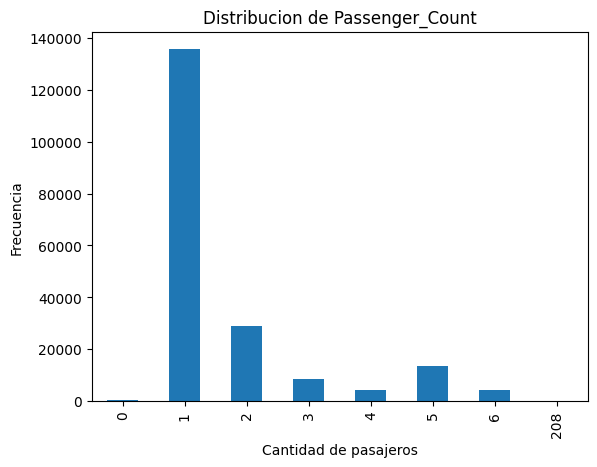

passenger_count
1      135491
2       28835
5       13722
3        8696
6        4184
4        4182
0         686
208         1
Name: count, dtype: int64

In [260]:
df_modelo["passenger_count"].value_counts().sort_index().plot(kind='bar')
plt.title("Distribucion de Passenger_Count")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Frecuencia")
plt.show()
df_modelo["passenger_count"].value_counts()


A partir de este gráfico de barras podemos observar un único valor outlier, el cual decidimos reemplazar por NaN para imputar luego. 

In [261]:
#Convertimos el valor 208 en nulo 
df_modelo["passenger_count"] = df_modelo["passenger_count"].replace(208, np.nan)

Cantidad de viajes con distancia = 0: 2038

Estadísticas de fare_amount en viajes con distancia = 0:
count    2038.000000
mean       11.101305
std        14.647066
min         2.500000
25%         4.900000
50%         6.500000
75%        10.100000
max       200.000000
Name: fare_amount, dtype: float64


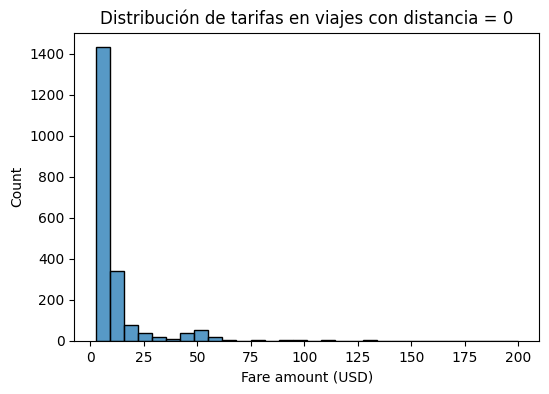

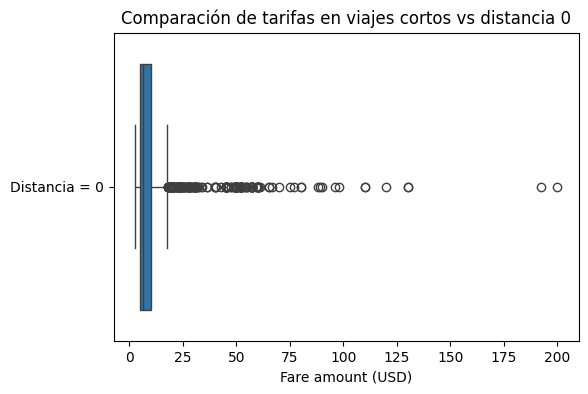

Cantidad de viajes con distancia 0 con tarifa mayor a 6.5: 1012


In [262]:
#Contamos cantidad de viajes con distancia 0
zero_dist = df_modelo[df_modelo["distance_km"] == 0]
print("Cantidad de viajes con distancia = 0:", len(zero_dist))

#Estadísticas
print("\nEstadísticas de fare_amount en viajes con distancia = 0:")
print(zero_dist["fare_amount"].describe())

#Histograma de estadísticas
plt.figure(figsize=(6,4))
sns.histplot(zero_dist["fare_amount"], bins=30, kde=False)
plt.xlabel("Fare amount (USD)")
plt.title("Distribución de tarifas en viajes con distancia = 0")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(
    data=[zero_dist["fare_amount"]],
    orient="h"
)

#Comparación de tarifas en viajes cortos y distancia 0
plt.yticks([0], ["Distancia = 0"])
plt.xlabel("Fare amount (USD)")
plt.title("Comparación de tarifas en viajes cortos vs distancia 0")
plt.show()

fa_atipicos = zero_dist[zero_dist["fare_amount"] > 6.5]["fare_amount"].shape[0]

print(f"Cantidad de viajes con distancia 0 con tarifa mayor a 6.5: {fa_atipicos}")


SPLIT
-----

In [263]:
X_train, X_test, y_train, y_test = train_test_split(df_modelo.drop(columns='fare_amount'), df_modelo['fare_amount'], test_size=0.2, random_state=42)


IMPUTACION DE VALORES FALTANTES EN COORDENADAS Y DISTANCIAS 
--------------------------------------------------------------

In [264]:
coords = ["pickup_latitude","pickup_longitude","dropoff_latitude","dropoff_longitude"]

invalidas = X_train[coords].isna().sum(axis=1)
filas_a_imputar = X_train[invalidas == 1].copy()


scaler = StandardScaler()
X_escaladas_train = scaler.fit_transform(filas_a_imputar[coords])

#Imputación KNN en X_train
imputer = KNNImputer(n_neighbors=5)
X_imputadas_train = imputer.fit_transform(X_escaladas_train)

#Volvemos a coordenadas originales en X_train
filas_a_imputar[coords] = scaler.inverse_transform(X_imputadas_train)

#Reintegración al X_train original
X_train.update(filas_a_imputar)

#Imputación en X_test usando los mismos scaler e imputador
invalidas_test = X_test[coords].isna().sum(axis=1)
filas_a_imputar_test = X_test[invalidas_test == 1].copy()

#Escalar X_test con scaler ya ajustado
X_escaladas_test = scaler.transform(filas_a_imputar_test[coords])

#Imputar usando imputador ya ajustado
X_imputadas_test = imputer.transform(X_escaladas_test )

#Volvemos a coordenadas originales en X_test
filas_a_imputar_test[coords] = scaler.inverse_transform(X_imputadas_test)


X_test.update(filas_a_imputar_test)



C:\Users\Usuario\AppData\Local\Temp\ipykernel_3360\2899629490.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  X_train.update(filas_a_imputar)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3360\2899629490.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 1 1 ... 1 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  X_train.update(filas_a_imputar)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3360\2899629490.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 1 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  X_train.update(filas_a_imputar)
C:\Users\Usuario\Ap

Se utilizó el algoritmo KNN para imputar las coordenadas faltantes, ya que permite estimar valores basados en la similitud con observaciones cercanas. Este enfoque aprovecha la estructura espacial de los datos, asegurando que las imputaciones mantengan coherencia geográfica y evitando sesgos que podrían surgir con métodos más simples como la media o la mediana.

In [265]:
#Recalcular la distancia por las coordenadas imputadas
X_train['distance_km'] = haversine_km(
    X_train['pickup_latitude'], X_train['pickup_longitude'],
    X_train['dropoff_latitude'], X_train['dropoff_longitude']
)

X_test['distance_km'] = haversine_km(
    X_test['pickup_latitude'], X_test['pickup_longitude'],
    X_test['dropoff_latitude'], X_test['dropoff_longitude']
)
   

### _DROP DE COORDENADAS_

In [266]:
##Dropeamos variables pickup_longitude, pickup_latitude, dropoff_longitude y dropoff_latitude

X_train = X_train.drop(columns=['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude'])
X_test  = X_test.drop(columns=['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude'])

df_modelo = df_modelo.drop(columns=['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude'])

In [267]:
#Se le pone pesos a las dummies de turnos
hora_cols = [col for col in X_train.columns if col.startswith("turno_")]

for col in hora_cols:
    X_train[col] = X_train["distance_km"] * X_train[col]

hora_cols_test = [col for col in X_test.columns if col.startswith("turno_")]

for col in hora_cols_test:
    X_test[col] = X_test["distance_km"] * X_test[col]

print(X_train[hora_cols].head())
print(X_test[hora_cols].head())


#Se le pone pesos a las dummies de mes
estacion_cols = [col for col in X_train.columns if col.startswith("estacion_")]  

estacion_cols_test = [col for col in X_test.columns if col.startswith("estacion_")]

for col in estacion_cols:
    X_train[col] = X_train["distance_km"] * X_train[col]
    X_test[col] = X_test["distance_km"] * X_test[col]

    
print(X_train[estacion_cols].head())


        turno_mañana  turno_tarde  turno_noche  turno_madrugada
35048       0.000000     6.635825     0.000000              0.0
192704      0.000000     0.000000     7.321762              0.0
8207        0.000000     9.996973     0.000000              0.0
197511      1.799962     0.000000     0.000000              0.0
156994      0.000000     2.924205     0.000000              0.0
        turno_mañana  turno_tarde  turno_noche  turno_madrugada
50579       0.000000     1.511811      0.00000              0.0
7436        1.760793     0.000000      0.00000              0.0
100232      0.000000     0.000000      2.55612              0.0
116413      0.000000     2.273266      0.00000              0.0
9327        0.000000     4.279693      0.00000              0.0
        estacion_verano  estacion_otoño  estacion_invierno  estacion_primavera
35048          0.000000        0.000000           0.000000            6.635825
192704         0.000000        7.321762           0.000000            0.00

Luego de crear dummies y ver los resultados del modelo, más especificamente en el gráfico de coeficientes del modelo lineal, observamos que la variable distancia era con diferencia la más preponderante al momento de predecir la tarifa, mientras que las demás variables no aportaban gran información al modelo. 

Al crear variables como distancia × dummy, lo que hacemos es que el modelo pueda estimar un coeficiente distinto por cada categoría, expresado en términos de “costo por kilómetro bajo esa condición”, en el intento de capturar efectos diferenciales en el precio según la categoría, en lugar de asumir un único costo por km para todos los casos.

Cabe aclarar que al analizarlo en profundidad advertimos que este procedimiento carece de fundamento metodológico: no se trata de una verdadera ponderación, sino de una distorsión al intentar "nivelar por la fuerza"; si la distancia presenta coeficientes más altos que las dummies, esto refleja su mayor poder explicativo y no un problema de balance que deba corregirse. 


### _IMPUTACION DE LOS VALORES DE FARE_AMOUNT DE LA DISTANCIA MENOR A 0,1_


In [268]:
# Encontrar la moda de las distancias menores a 0.1 (100m)
zero_dist_train = y_train[X_train["distance_km"] < 0.1]
moda_fare_train = zero_dist_train.mode()[0]

# Imputar en train usando esa moda
y_train.loc[X_train["distance_km"] < 0.1] = moda_fare_train


In [269]:
mask_train = X_train["distance_km"] < 0.1

#Chequear cantidad de casos:
print("Filas a imputar en train:", mask_train.sum())

#Aplicar la moda:
y_train.loc[mask_train] = moda_fare_train


Filas a imputar en train: 2533


Al analizar las distancias menores a 0.1 km nos encontramos con que tenían valores de tarifas muy elevados. Para no descartarlos, decidimos imputar dichos valores por la moda calculada en ese rango de distancia (0km a 0.1km), ya que consideramos que era la métrica más representativa. 

### _RATIO PRECIO/DISTANCIA_


Siguiendo el análisis y tratamiento de outliers, se creó una nueva columna temporal que refleja la relación entre el precio y la distancia en metros, con el objetivo de detectar viajes cuyo costo resultaba excesivo en relación a su recorrido. 

A partir de esta métrica se definió un umbral de referencia, y todos los registros que presentaban un costo por metro superior a dicho valor fueron identificados como inconsistentes. 

En lugar de eliminarlos, se optó por imputar sus valores de fare amount (en train) utilizando la distancia del viaje y el costo promedio por metro obtenido del resto del conjunto de datos, asegurando así coherencia en la información sin perder registros útiles. 

In [270]:
# Aseguramos que y_train sea vector 1D alineado con X_train
y_train = np.array(y_train).reshape(-1) 
y_train = pd.Series(y_train, index=X_train.index)

# Inicializamos columna
X_train["costo_por_metro"] = np.nan

# Máscara de distancias válidas
mask_train = X_train["distance_km"] >= 0.1

# División elemento a elemento
X_train.loc[mask_train, "costo_por_metro"] = (
    y_train[mask_train] / (X_train.loc[mask_train, "distance_km"] * 1000)
)


In [271]:
umbral = 0.02

# Máscara de outliers
mask_outliers = X_train["costo_por_metro"] > umbral

# Calcular media de costo_por_km SOLO en los que no son outliers
mean_cpk = X_train.loc[~mask_outliers, "costo_por_metro"].mean()


y_train[mask_outliers] = (
    X_train.loc[mask_outliers, "distance_km"] * mean_cpk
)

#Dropeamos la columna auxiliar
X_train = X_train.drop(columns=["costo_por_metro"])

print("Outliers detectados:", mask_outliers.sum())
print("Media costo/km usada:", mean_cpk)
X_train[mask_outliers]

Outliers detectados: 903
Media costo/km usada: 0.0042825171654250396


,passenger_count,distance_km,is_holiday,is_workday,turno_mañana,turno_tarde,turno_noche,turno_madrugada,estacion_verano,estacion_otoño,estacion_invierno,estacion_primavera,uber_comun,uber_grande
193806,1.0,0.320520,0,1,0.32052,0.000000,0.000000,0.000000,0.320520,0.000000,0.000000,0.00000,1,0
177032,1.0,1.208110,0,1,0.00000,0.000000,1.208110,0.000000,1.208110,0.000000,0.000000,0.00000,1,0
105079,1.0,0.142000,1,0,0.00000,0.142000,0.000000,0.000000,0.000000,0.142000,0.000000,0.00000,1,0
168150,1.0,0.282948,0,0,0.00000,0.000000,0.282948,0.000000,0.282948,0.000000,0.000000,0.00000,1,0
128181,1.0,0.631684,0,1,0.00000,0.000000,0.000000,0.631684,0.631684,0.000000,0.000000,0.00000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143959,1.0,0.252980,0,1,0.25298,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.25298,1,0
44969,4.0,0.244219,0,0,0.00000,0.000000,0.244219,0.000000,0.000000,0.244219,0.000000,0.00000,1,0
185623,2.0,0.257002,0,0,0.00000,0.257002,0.000000,0.000000,0.000000,0.000000,0.257002,0.00000,1,0
101430,1.0,2.927981,0,1,0.00000,2.927981,0.000000,0.000000,0.000000,0.000000,2.927981,0.00000,1,0


IMPUTACION DE PASAJEROS POR LA MODA
-----------------------------------

In [272]:

##imputamos valor nulo de passenger_count por la moda
moda_passenger = X_train["passenger_count"].mode()[0]
X_train["passenger_count"].fillna(moda_passenger, inplace=True)
X_test["passenger_count"].fillna(moda_passenger, inplace=True)  
#Borro passenger_count porque ya tengo las dummies
X_train = X_train.drop(columns=['passenger_count'])
X_test  = X_test.drop(columns=['passenger_count'])
df_modelo = df_modelo.drop(columns=['passenger_count'])

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3360\3537679703.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["passenger_count"].fillna(moda_passenger, inplace=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3360\3537679703.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

Consideramos imputar el único valor atípico de cantidad de pasajeros por la moda, ya que era el único feature erroneo de la fila, en lugar de eliminarla. 

## _ESTADÍSTICAS_ 

In [273]:
print("\n--- Estadísticas TRAIN ---")
print(X_train.describe(include="all").transpose())



--- Estadísticas TRAIN ---
                       count      mean       std  min       25%       50%  \
distance_km         156637.0  3.325664  3.756521  0.0  1.257801  2.157035   
is_holiday          156637.0  0.029374  0.168852  0.0  0.000000  0.000000   
is_workday          156637.0  0.548632  0.497631  0.0  0.000000  1.000000   
turno_mañana        156637.0  0.898190  2.518386  0.0  0.000000  0.000000   
turno_tarde         156637.0  1.074422  2.607423  0.0  0.000000  0.000000   
turno_noche         156637.0  0.736789  2.190946  0.0  0.000000  0.000000   
turno_madrugada     156637.0  0.616262  2.084853  0.0  0.000000  0.000000   
estacion_verano     156637.0  0.800826  2.409291  0.0  0.000000  0.000000   
estacion_otoño      156637.0  0.781913  2.293553  0.0  0.000000  0.000000   
estacion_invierno   156637.0  0.804360  2.272484  0.0  0.000000  0.000000   
estacion_primavera  156637.0  0.938565  2.482274  0.0  0.000000  0.000000   
uber_comun          156637.0  0.904844  0.293432

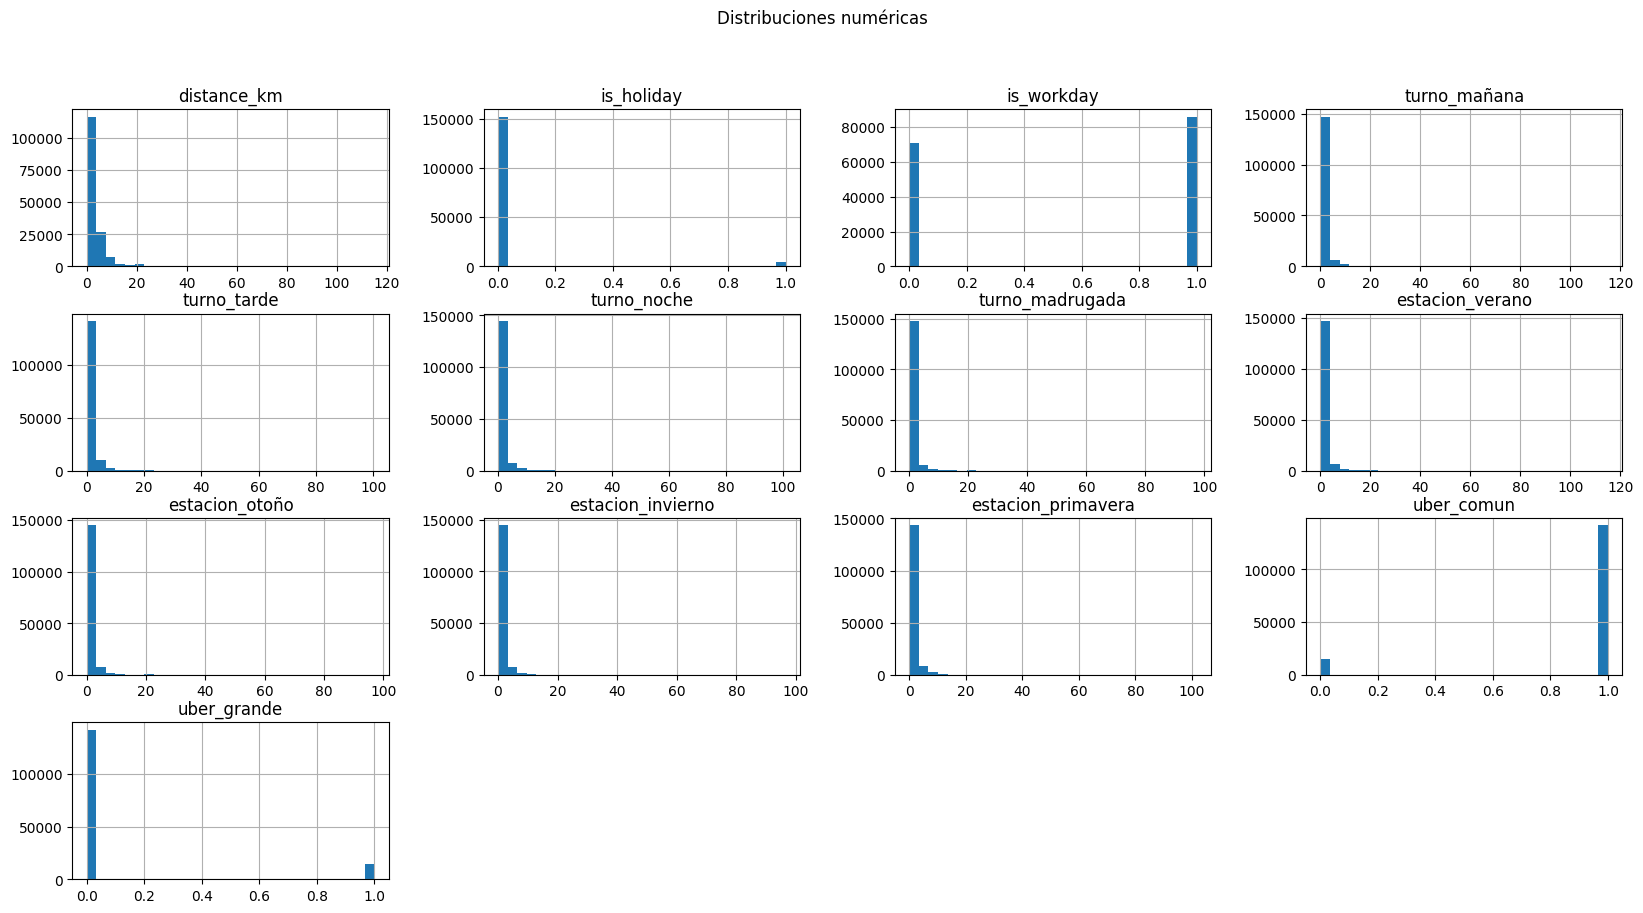

In [274]:
# Histogramas de variables numéricas
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
X_train[num_cols].hist(bins=30, figsize=(20,10))
plt.suptitle("Distribuciones numéricas")
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3360\1577048910.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train[col], label="Train", shade=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_3360\1577048910.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_test[col], label="Test", shade=True)


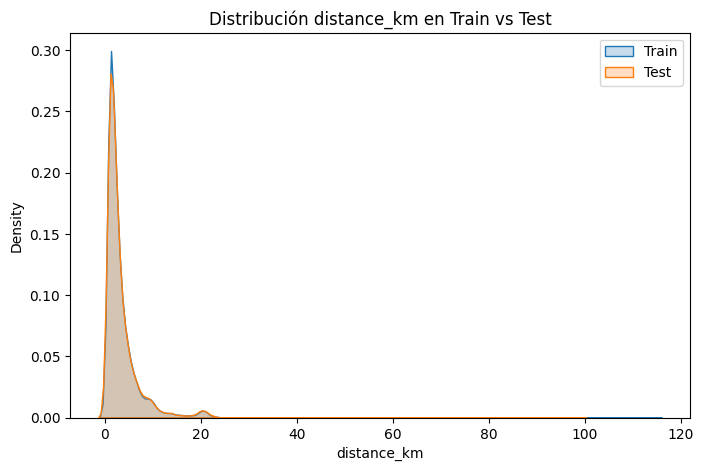

In [275]:

col = "distance_km" 
plt.figure(figsize=(8,5))
sns.kdeplot(X_train[col], label="Train", shade=True)
sns.kdeplot(X_test[col], label="Test", shade=True)
plt.title(f"Distribución {col} en Train vs Test")
plt.legend()
plt.show()

El gráfico de densidad de las distancias muestra cómo se distribuyen los viajes en el dataset. Podemos identificar cuáles son las distancias más frecuentes, observando los picos del histograma suavizado.

23682     206.38
197493    230.00
dtype: float64

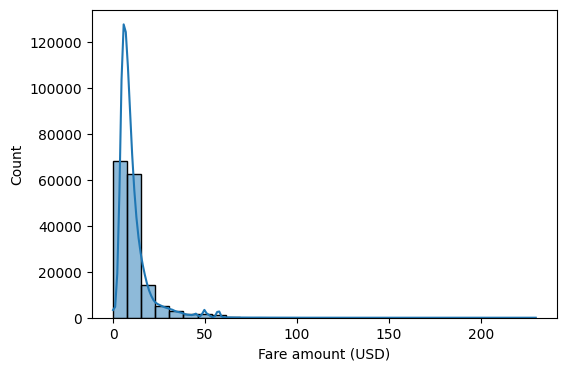

In [276]:
# Histograma  de fare_amount
plt.figure(figsize=(6,4))   
sns.histplot(y_train, bins=30, kde=True)
plt.xlabel("Fare amount (USD)")
##fare_amount mayores a 200
y_train[y_train > 200]

El histograma de fare_amount permite visualizar la distribución de los valores de los viajes. Se observa que la mayoría de los viajes tienen tarifas bajas, concentrándose en rangos menores, mientras que existen pocos viajes con tarifas muy altas, lo que indica la presencia de valores atípicos o outliers

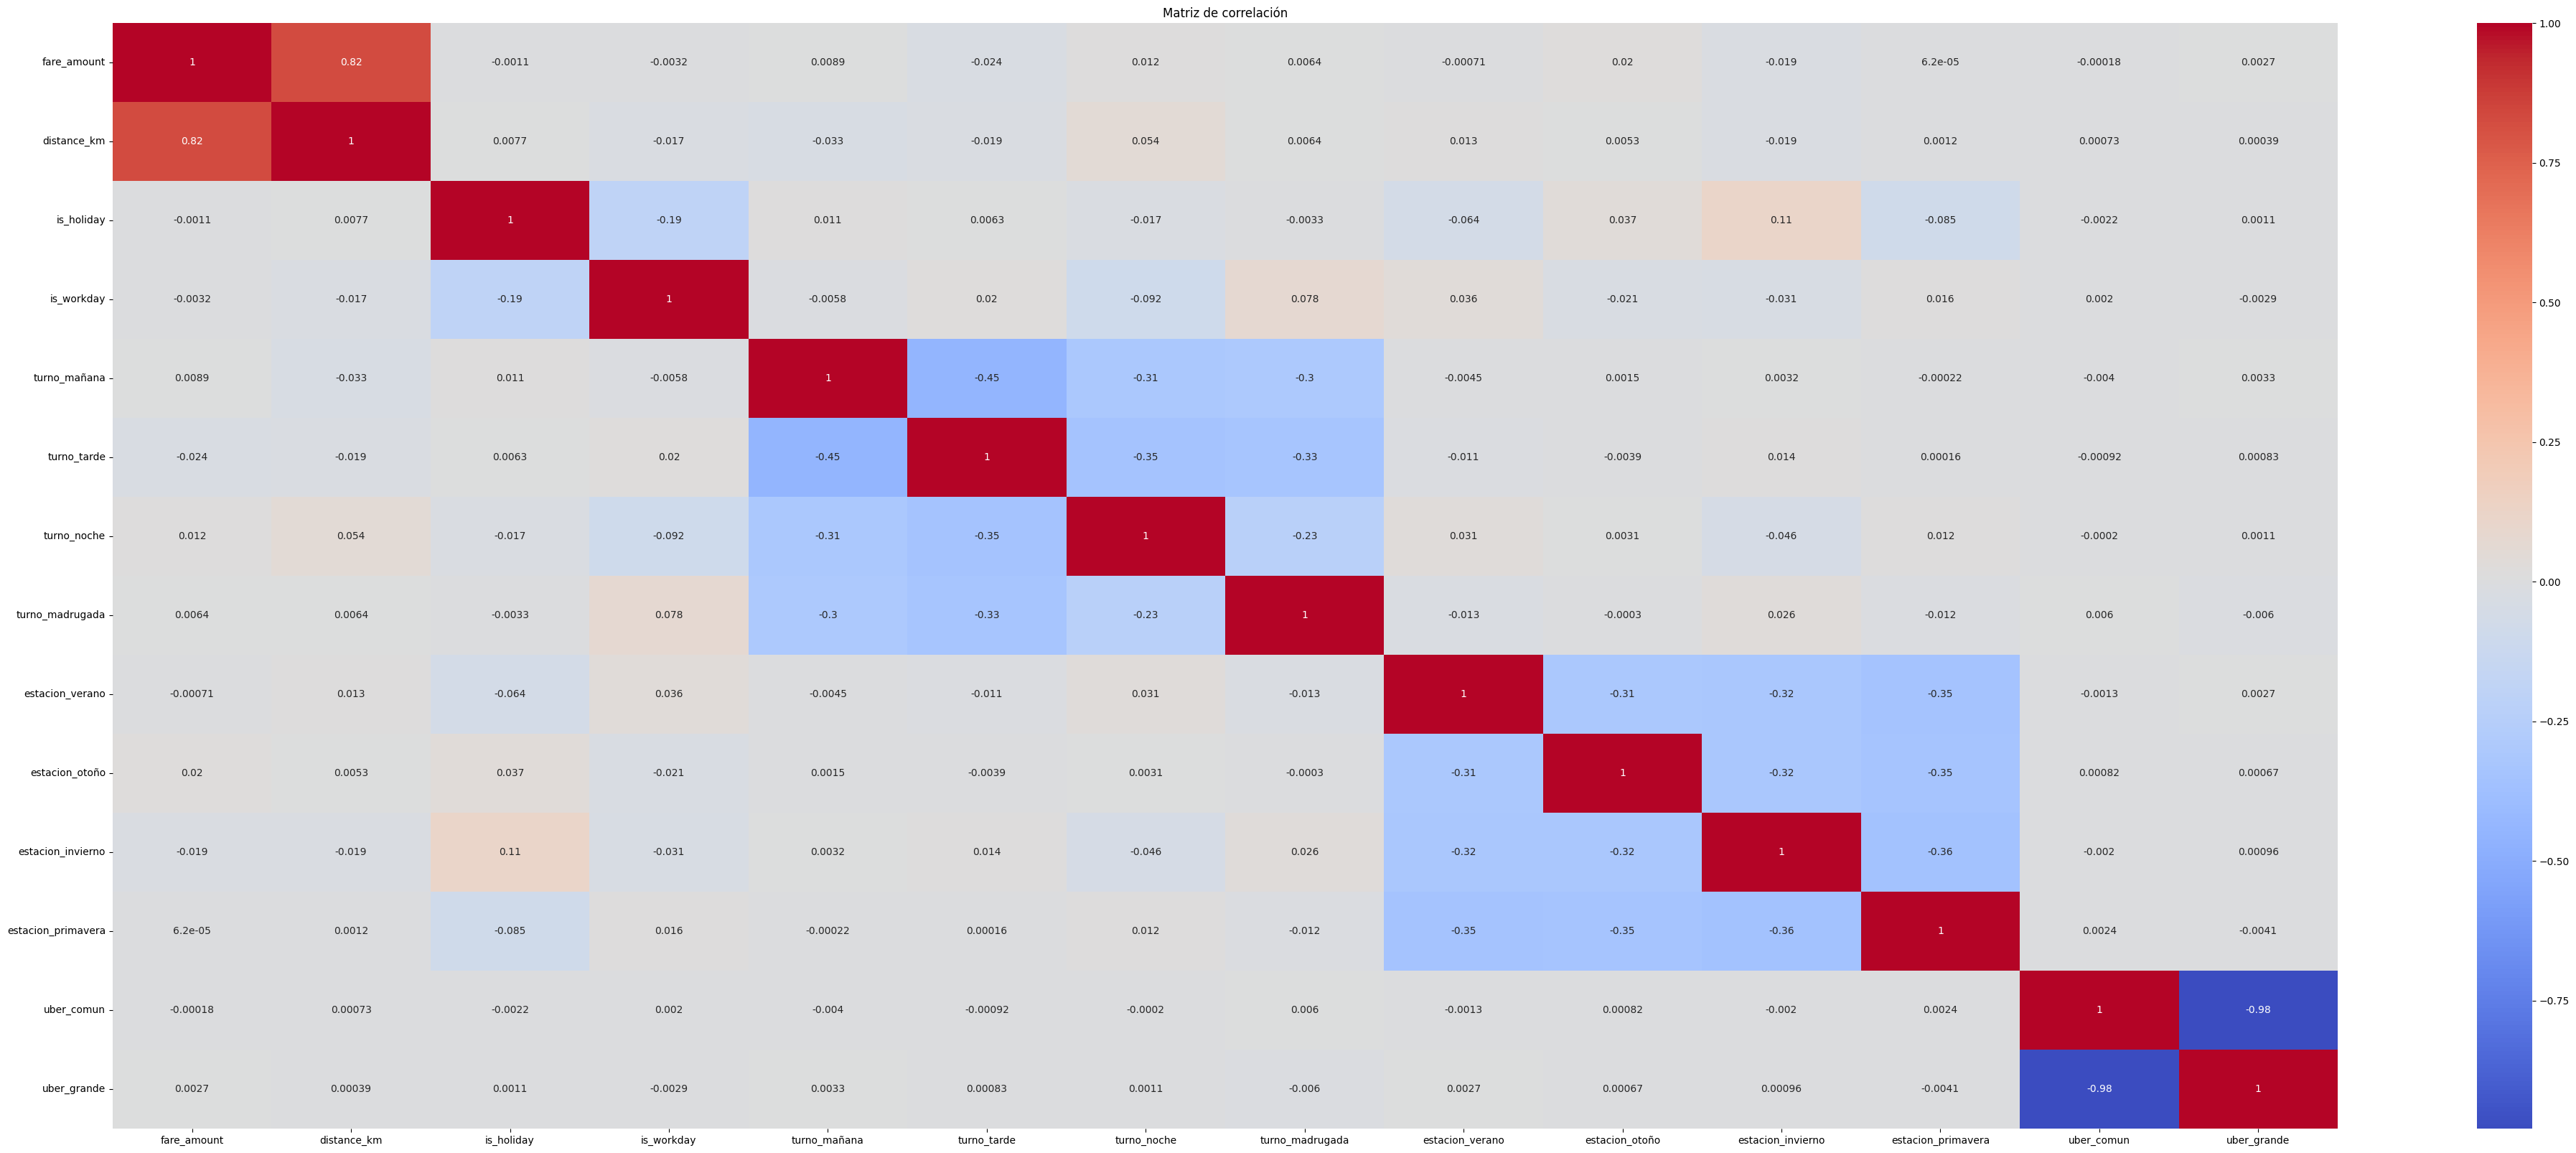

In [277]:
corr = df_modelo.corr()

plt.figure(figsize=(50,20))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()


El gráfico de correlación muestra la relación entre las distintas variables del dataset y el target. Se observa que la variable distance_km es la que tiene la correlación más fuerte con el valor del viaje, mientras que el resto de las variables presentan correlaciones bajas o casi nulas, lo que indica que su aporte predictivo individual es menor. Esto refuerza la importancia de la distancia como predictor principal.

ENTRENAMIENTO 
-------------

In [278]:

# Definir columnas numéricas y categóricas
num_cols = ["distance_km", "turno_mañana", "turno_tarde", "turno_noche", "turno_madrugada", "estacion_verano", "estacion_otoño", "estacion_invierno", "estacion_primavera"]
cat_cols = ["is_holiday", "is_workday", "uber_comun", "uber_grande"]


# Preprocesador: escalar numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough", cat_cols)
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough", cat_cols)
    ]
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

LINEAL
------

In [319]:
pipe_lr = make_pipeline(
    preprocessor,
    LinearRegression()
)

# Entrenamos el pipeline con training set
pipe_lr.fit(X=X_train, y = y_train)

# Predicciones sobre train y test
y_train_pred = pipe_lr.predict(X_train)
y_test_pred = pipe_lr.predict(X_test)

print("Entrenamiento:")
### RMSE calcular el RMSE
rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print("RMSE:", rmse)
print("R²:", r2_score(y_train, y_train_pred))

print("\nPrueba:")
rmse_ols = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("RMSE:", rmse_ols)
print("R²:", r2_score(y_test, y_test_pred))



Entrenamiento:
RMSE: 4.529110863567308
R²: 0.7686376078869454

Prueba:
RMSE: 5.296238727318089
R²: 0.7102345385120316


Los resultados obtenidos muestran un buen desempeño del modelo. En el conjunto de entrenamiento se alcanzó un RMSE de 4,53 y un R² de 0,77, mientras que en el conjunto de prueba los valores fueron de 5,32 y 0,71 respectivamente. Estas métricas indican que el modelo logra explicar una proporción significativa de la variabilidad del fare amount y mantiene una capacidad predictiva aceptable al generalizar a datos no vistos.

Es importante remarcar, sin embargo, que el conjunto de prueba no fue filtrado de la misma manera que el de entrenamiento, por lo que aún contiene outliers y registros inconsistentes. En consecuencia, parte del error observado en la prueba se debe a la calidad de los datos y no necesariamente a fallas en el modelo en sí. Dado que conocemos la naturaleza de los datos y hemos identificado estas anomalías, podemos concluir que el modelo predice de manera adecuada dentro del rango esperado, pero que las métricas de prueba reflejan también la presencia de valores atípicos no tratados.

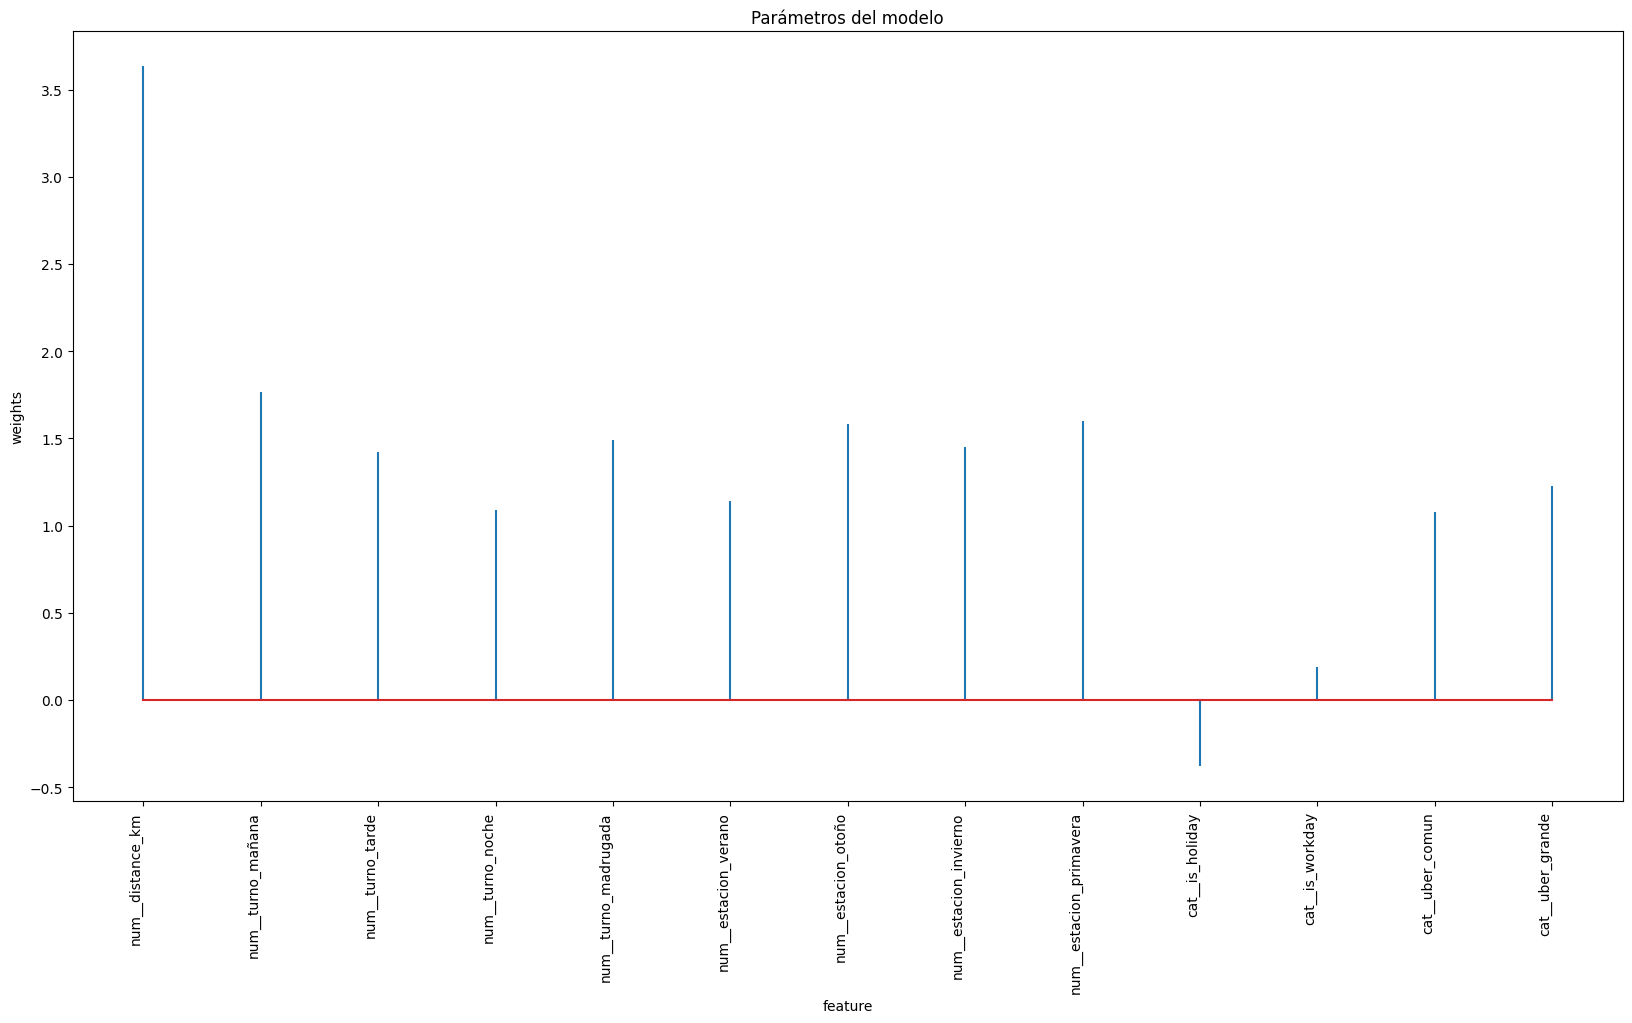

In [280]:

preprocessor = pipe_lr.named_steps["columntransformer"]

feature_names = preprocessor.get_feature_names_out()

df_coeficientes = pd.DataFrame({
    "predictor": feature_names,
    "coef": pipe_lr.named_steps["linearregression"].coef_.flatten()
})

fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('weights')
ax.set_title('Parámetros del modelo');

Se observa que la distancia en kilómetros es el factor más influyente en la predicción del precio, mientras que las variables categóricas ajustadas por distancia reflejan variaciones en el costo por kilómetro según turno, estación del año, tipo de servicio y condiciones especiales (feriados o días laborables). Tenemos en cuenta que si no poderaramos las dummies los coeficientes de éstas en el gráfico son casi despreciables. 


In [281]:
# Predicciones test

predicciones_lnr = pipe_lr.predict(X=X_test)
predicciones_lnr = predicciones_lnr.flatten()
predicciones_lnr[:10]

array([ 7.14152294,  7.65042593,  9.41398432,  8.70448344, 13.1119577 ,
       17.04061107, 25.71778018,  7.33278806,  6.56490305, 13.30933894])

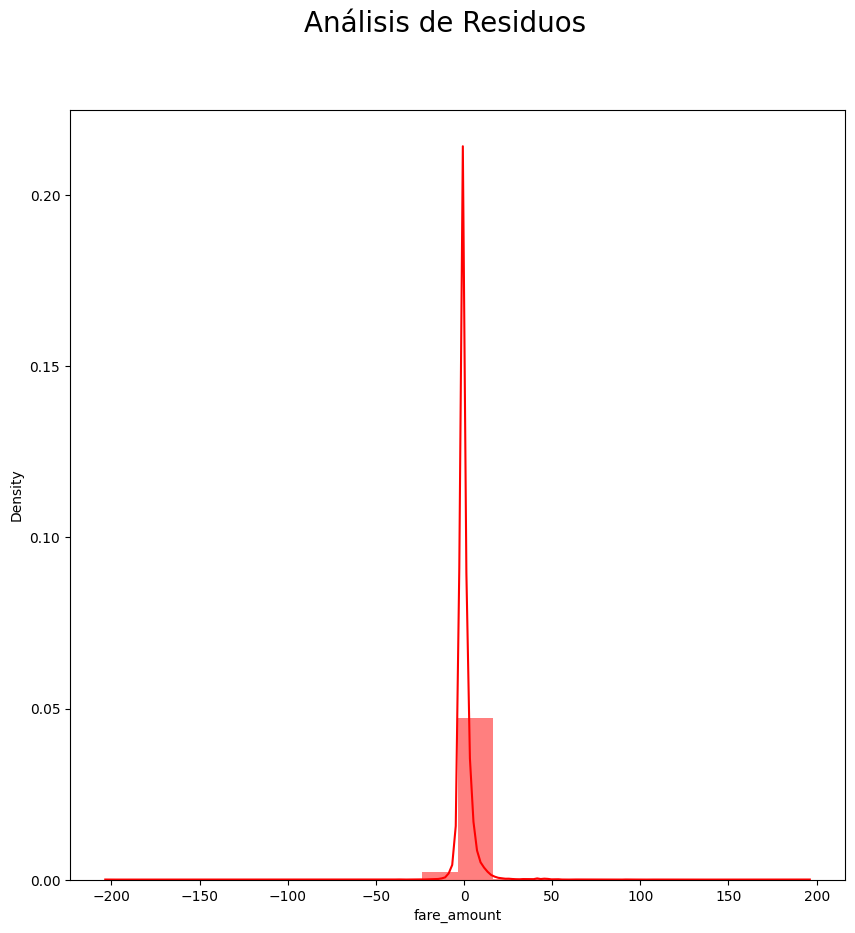

In [282]:
fig = plt.figure(figsize=(10,10))
  
sns.histplot((y_test - predicciones_lnr.reshape(y_test.shape)), color="red", kde=True, stat="density", linewidth=0,bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)    
plt.show()

Se detectaron 443 outliers
     y_real     y_pred    residuo
6      4.10  25.717780 -21.617780
23    57.54  41.079636  16.460364
104    3.30  30.700761 -27.400761
129   89.80  53.259064  36.540936
189   49.57   6.288775  43.281225


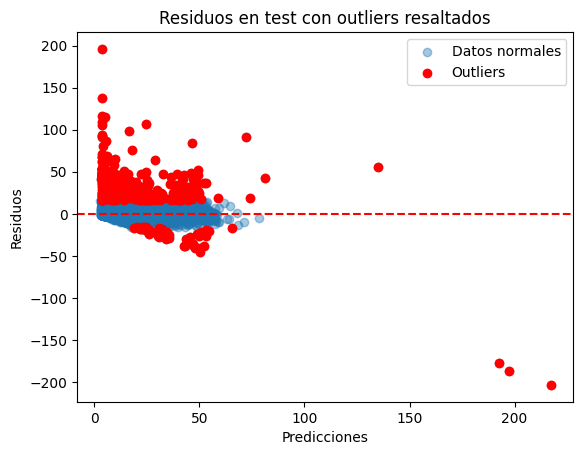

In [283]:
#Convierte a array 1D
y_real = np.ravel(y_test)
y_pred = np.ravel(y_test_pred)   

residuos = y_real - y_pred

# Calcular media y desvío estándar
mean_res = np.mean(residuos)
std_res = np.std(residuos)

# Definir umbral (3 sigmas)
umbral = 3 * std_res

# Detectar outliers
outliers_mask = np.abs(residuos - mean_res) > umbral
outliers = pd.DataFrame({
    "y_real": y_real,
    "y_pred": y_pred,
    "residuo": residuos
})[outliers_mask]

print(f"Se detectaron {outliers.shape[0]} outliers")
print(outliers.head())

# Gráfico con outliers resaltados
plt.scatter(y_pred, residuos, alpha=0.4, label="Datos normales")
plt.scatter(outliers["y_pred"], outliers["residuo"], color="red", label="Outliers")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.legend()
plt.title("Residuos en test con outliers resaltados")
plt.show()


GRADIENTES 
----------

In [284]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42)

Se dividió nuevamente el conjunto de entrenamiento para obtener un subconjunto de validación. Esto se hizo para poder probar distintos valores de alpha durante el entrenamiento y ver cómo cambiaba el rendimiento del modelo sin usar todavía el conjunto de prueba. De esta manera se puede elegir el nivel de regularización más adecuado y mantener el test reservado únicamente para la evaluación final.

In [285]:
X_train_scaled = preprocessor.fit_transform(X_train) 
X_val_scaled   = preprocessor.transform(X_val)       
X_test_scaled  = preprocessor.transform(X_test)

In [286]:
X_train_scaled.shape, X_val_scaled.shape, X_test.shape

((137057, 13), (19580, 13), (39160, 13))

In [287]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(137057,)
(19580,)
(39160,)


In [288]:
y_train = y_train.values.reshape(-1,1)
y_val   = y_val.values.reshape(-1,1)
y_test  = y_test.values.reshape(-1,1)

### _GRADIENTE DESCENDIENTE_

Época 0/100 - Train RMSE: 14.5342 - Val RMSE: 14.4302
Época 10/100 - Train RMSE: 4.7572 - Val RMSE: 4.6460
Época 20/100 - Train RMSE: 4.6621 - Val RMSE: 4.5555
Época 30/100 - Train RMSE: 4.6081 - Val RMSE: 4.5027
Época 40/100 - Train RMSE: 4.5770 - Val RMSE: 4.4724
Época 50/100 - Train RMSE: 4.5588 - Val RMSE: 4.4549
Época 60/100 - Train RMSE: 4.5481 - Val RMSE: 4.4448
Época 70/100 - Train RMSE: 4.5417 - Val RMSE: 4.4390
Época 80/100 - Train RMSE: 4.5379 - Val RMSE: 4.4356
Época 90/100 - Train RMSE: 4.5356 - Val RMSE: 4.4336
R2:0.7716280714725225


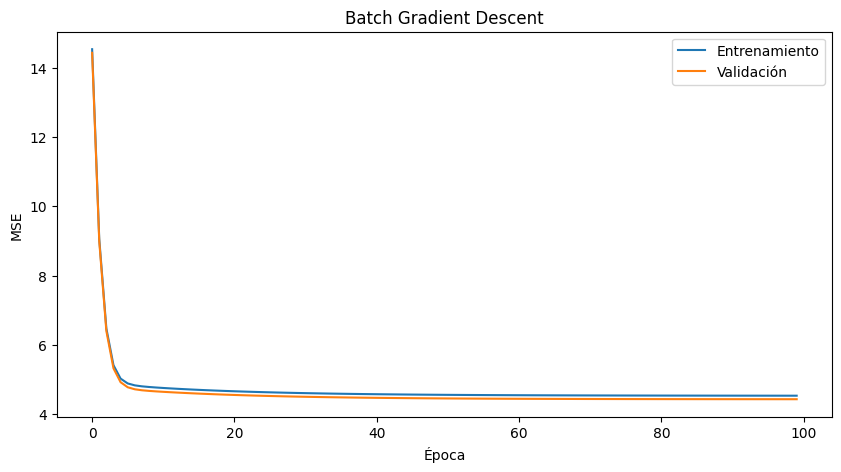

In [320]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.1, epochs=100, schedule=False):
    n, m = X_train.shape
    o = X_val.shape[0]

    # Agregar columna de unos
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val   = np.hstack((np.ones((o, 1)), X_val))

    # Asegurar vectores columna
    y_train = y_train.reshape(-1, 1)
    y_val   = y_val.reshape(-1, 1)

    # Inicializar pesos en cero
    W = np.zeros((m+1, 1))

    train_errors = []
    val_errors = []

    for ep in range(epochs):
        # Predicción entrenamiento
        pred_train = X_train @ W
        error_train = y_train - pred_train

        # MSE entrenamiento
        train_rmse = np.sqrt(np.mean(error_train**2))
        train_errors.append(train_rmse)

        # Predicción validación
        pred_val = X_val @ W
        error_val = y_val - pred_val
        r2_gd = r2_score(y_val, pred_val)
        
        # RMSE validación
        val_rmse = np.sqrt(np.mean(error_val**2))
        val_errors.append(val_rmse)


        # Gradiente vectorizado: -(2/n) Xᵀ (y - XW)
        grad = -(2/n) * (X_train.T @ error_train)

        # Learning rate con schedule opcional
        lr_t = lr / np.sqrt(ep+1) if schedule else lr
        W -= lr_t * grad

        if ep % 10 == 0:
            print(f"Época {ep}/{epochs} - Train RMSE: {train_rmse:.4f} - Val RMSE: {val_rmse:.4f}")
        
    print(f"R2:{r2_gd}")        
            


    # Graficar
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Entrenamiento')
    plt.plot(val_errors, label='Validación')
    plt.xlabel('Época')
    plt.ylabel('MSE')
    plt.legend()
    plt.title('Batch Gradient Descent')
    plt.show()

    return W



W_batch = gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, lr=0.1, epochs=100)



Se observa una fuerte disminución del error en las primeras épocas, seguida de una estabilización progresiva tanto en el conjunto de entrenamiento como en el de validación. La cercanía entre ambas curvas indica que el modelo generaliza adecuadamente y no presenta signos de sobreajuste, alcanzando un punto de convergencia estable en torno a un MSE cercano a 4,5.

### _GRADIENTE ESTOCÁSTICO_

Época 1/30 - Train RMSE: 7.6764 - Test RMSE: 7.5703
Época 2/30 - Train RMSE: 6.3536 - Test RMSE: 6.2539
Época 3/30 - Train RMSE: 5.8374 - Test RMSE: 5.7549
Época 4/30 - Train RMSE: 5.4739 - Test RMSE: 5.3764
Época 5/30 - Train RMSE: 5.3123 - Test RMSE: 5.2171
Época 6/30 - Train RMSE: 5.1818 - Test RMSE: 5.0766
Época 7/30 - Train RMSE: 5.1030 - Test RMSE: 5.0028
Época 8/30 - Train RMSE: 5.0036 - Test RMSE: 4.9015
Época 9/30 - Train RMSE: 4.9551 - Test RMSE: 4.8389
Época 10/30 - Train RMSE: 4.9089 - Test RMSE: 4.7855
Época 11/30 - Train RMSE: 4.8879 - Test RMSE: 4.7579
Época 12/30 - Train RMSE: 4.8603 - Test RMSE: 4.7219
Época 13/30 - Train RMSE: 4.8472 - Test RMSE: 4.6982
Época 14/30 - Train RMSE: 4.8407 - Test RMSE: 4.6897
Época 15/30 - Train RMSE: 4.8340 - Test RMSE: 4.6810
Época 16/30 - Train RMSE: 4.8259 - Test RMSE: 4.6716
Época 17/30 - Train RMSE: 4.8316 - Test RMSE: 4.6719
Época 18/30 - Train RMSE: 4.8191 - Test RMSE: 4.6601
Época 19/30 - Train RMSE: 4.8084 - Test RMSE: 4.6452
Ép

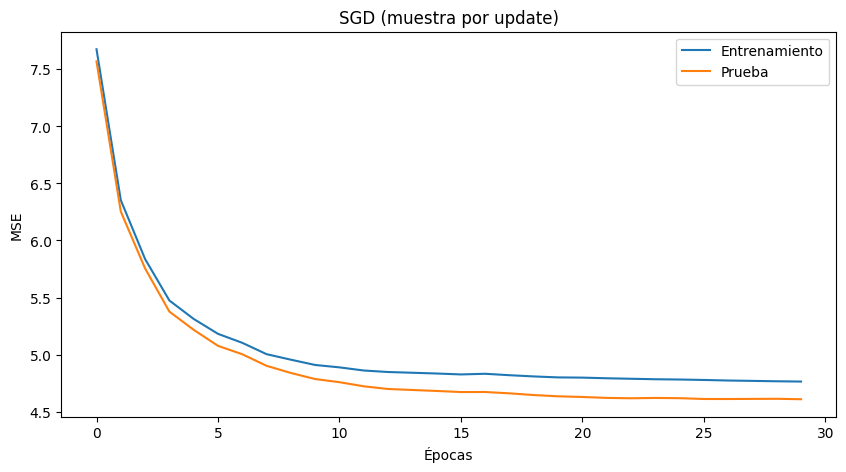

In [321]:
def stochastic_gradient_descent(
    X_train, y_train, X_test, y_test,
    lr=0.001, epochs=20, updates_per_epoch=10000, schedule=True
):
    n, m = X_train.shape

    # Agregar bias
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test  = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.zeros((m + 1, 1))  # pesos iniciales

    train_errors, test_errors = [], []
    t = 0  # contador de updates totales

    for ep in range(epochs):
        # indices aleatorios para elegir muestras
        idx = np.random.permutation(n)
        k = min(updates_per_epoch, n)   # límite de updates por época
        pick = idx[:k]

        for j in pick:
            x_sample = X_train[j:j+1]   # (1, m+1)
            y_sample = y_train[j:j+1]   # (1, 1)

            prediction = x_sample @ W
            error = y_sample - prediction

            gradient = -2 * (x_sample.T @ error)
            lr_t = lr / np.sqrt(t+1) if schedule else lr
            W -= lr_t * gradient
            t += 1

        # calcular errores por época
        train_pred = X_train @ W
        train_rmse = np.sqrt(np.mean((y_train - train_pred)**2))
        train_errors.append(train_rmse)

        test_pred = X_test @ W
        test_rmse = np.sqrt(np.mean((y_test - test_pred)**2))
        test_errors.append(test_rmse)

        print(f"Época {ep+1}/{epochs} - Train RMSE: {train_rmse:.4f} - Test RMSE: {test_rmse:.4f}")
        

    r2_sgd = r2_score(y_test, test_pred)
    print(f"R2:{r2_sgd}")      
    
    # gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Entrenamiento')
    plt.plot(test_errors, label='Prueba')
    plt.xlabel('Épocas')
    plt.ylabel('MSE')
    plt.legend()
    plt.title('SGD (muestra por update)')
    plt.show()

    return W


# Ejecutar SGD
W_sgd = stochastic_gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, lr=0.001, epochs=30)


Se observa una clara disminución del error tanto en el conjunto de entrenamiento como en el de prueba, alcanzando valores estables y cercanos entre sí, lo que indica un buen nivel de generalización del modelo. La elección de un learning rate bajo junto con 30 épocas resulta adecuada para lograr una convergencia progresiva y estable, sin oscilaciones ni divergencias. Si se incrementara el número de épocas, la mejora sería marginal dado que el modelo ya se encuentra próximo a su punto de convergencia, además de que el costo computacional sería elevado; en cambio, un aumento en el learning rate podría acelerar la reducción inicial del error, pero al costo de introducir inestabilidad en el proceso y riesgo de que el modelo no converja correctamente.

### _MINI BATCH_

Época 1/200 - Train RMSE: 5.0499 - Test RMSE: 4.9552
Época 2/200 - Train RMSE: 4.8285 - Test RMSE: 4.7226
Época 3/200 - Train RMSE: 4.7802 - Test RMSE: 4.6724
Época 4/200 - Train RMSE: 4.7560 - Test RMSE: 4.6476
Época 5/200 - Train RMSE: 4.7398 - Test RMSE: 4.6317
Época 6/200 - Train RMSE: 4.7268 - Test RMSE: 4.6187
Época 7/200 - Train RMSE: 4.7160 - Test RMSE: 4.6083
Época 8/200 - Train RMSE: 4.7066 - Test RMSE: 4.5984
Época 9/200 - Train RMSE: 4.6983 - Test RMSE: 4.5907
Época 10/200 - Train RMSE: 4.6909 - Test RMSE: 4.5837
Época 11/200 - Train RMSE: 4.6841 - Test RMSE: 4.5769
Época 12/200 - Train RMSE: 4.6779 - Test RMSE: 4.5707
Época 13/200 - Train RMSE: 4.6722 - Test RMSE: 4.5655
Época 14/200 - Train RMSE: 4.6669 - Test RMSE: 4.5603
Época 15/200 - Train RMSE: 4.6621 - Test RMSE: 4.5556
Época 16/200 - Train RMSE: 4.6575 - Test RMSE: 4.5511
Época 17/200 - Train RMSE: 4.6533 - Test RMSE: 4.5469
Época 18/200 - Train RMSE: 4.6493 - Test RMSE: 4.5430
Época 19/200 - Train RMSE: 4.6456 - T

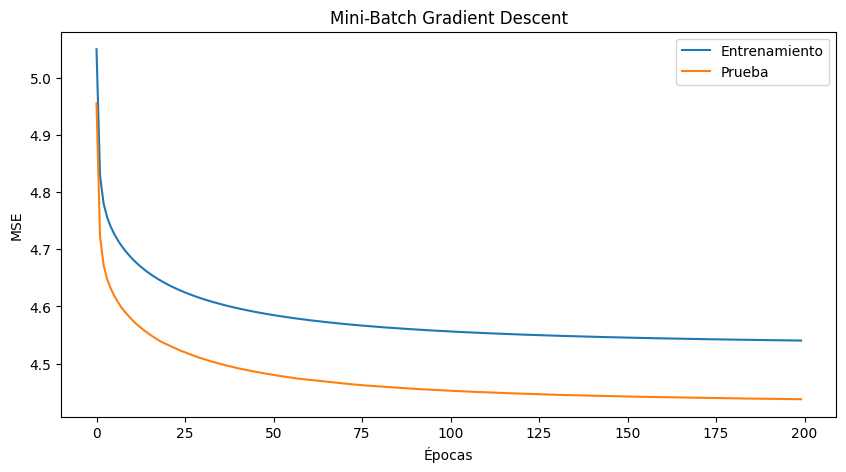

In [324]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test,
                                lr=0.01, epochs=20, batch_size=32, schedule=True):
    n, m = X_train.shape

    # Agregar bias
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test  = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    # Asegurar que y sean vectores columna
    y_train = y_train.reshape(-1, 1)
    y_test  = y_test.reshape(-1, 1)

    # Inicializar pesos
    W = np.zeros((m + 1, 1))

    train_errors, test_errors = [], []
    t = 0  # contador de updates

    for ep in range(epochs):
        # Permutar aleatoriamente
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        # Recorrer en lotes
        for j in range(0, n, batch_size):
            x_batch = X_train[j:j+batch_size]
            y_batch = y_train[j:j+batch_size]

            prediction = x_batch @ W
            error = y_batch - prediction

            gradient = -(2 / len(x_batch)) * (x_batch.T @ error)
            lr_t = lr / np.sqrt(t+1) if schedule else lr
            W -= lr_t * gradient
            t += 1

        # calcular errores globales por época
        train_rmse = np.sqrt(np.mean((y_train - (X_train @ W))**2))
        test_rmse  = np.sqrt(np.mean((y_test  - (X_test  @ W))**2))

        train_errors.append(train_rmse)
        test_errors.append(test_rmse)

        print(f"Época {ep+1}/{epochs} - Train RMSE: {train_rmse:.4f} - Test RMSE: {test_rmse:.4f}")

    
    r2_mb = r2_score(y_test, X_test @ W)
    print(f"R2:{r2_mb}")  
    
    # gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Entrenamiento')
    plt.plot(test_errors, label='Prueba')
    plt.xlabel('Épocas')
    plt.ylabel('MSE')
    plt.legend()
    plt.title('Mini-Batch Gradient Descent')
    plt.show()

    return W


W_mini = mini_batch_gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, lr=0.01, epochs=200, batch_size=200)



El error desciende de forma estable tanto en entrenamiento como en prueba, mostrando que el modelo aprende bien y generaliza correctamente. El uso de mini-lotes hace que el aprendizaje sea más eficiente y estable, y aunque con más épocas el error sigue bajando, la mejora es cada vez menor, lo que indica que el modelo ya está cerca de su convergencia.

REGULARIZACIÓN
--------------


### _RIDGE_

In [292]:

modelo_ridge = RidgeCV(
    alphas = np.logspace(-4, 4, 100),
    cv=5,
    fit_intercept=True,
)
modelo_ridge.fit(X_train_scaled, y_train)

# Evaluar en el set de validación
y_val_pred = modelo_ridge.predict(X_val_scaled)
mse_val = mean_squared_error(y_val, y_val_pred)
print("MSE en validación:", mse_val)


MSE en validación: 19.61668458124807


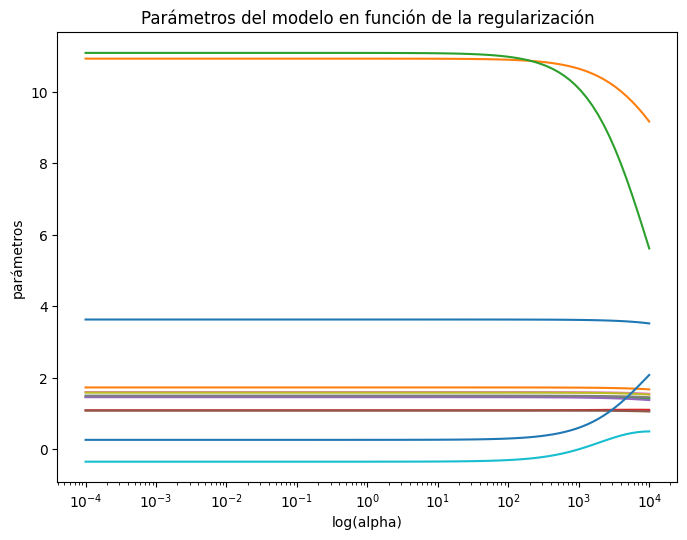

In [293]:

alphas = modelo_ridge.alphas
coefs = []

for alpha in alphas:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train_scaled, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(8, 5.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('log(alpha)')
ax.set_ylabel('parámetros')
ax.set_title('Parámetros del modelo en función de la regularización');
plt.axis('tight')
plt.show()

Se observa que, para valores bajos de alpha, los coeficientes se mantienen altos y estables. A medida que la regularización aumenta, algunos parámetros comienzan a reducirse, lo que muestra cómo el modelo limita la influencia de ciertas variables. Esto refleja el efecto de la regularización: evitar que los coeficientes crezcan demasiado y mantener el modelo más simple y equilibrado.
Al aumentar el parámetro de regularización, los coeficientes se reducen, lo que hace al modelo más estable pero con menor capacidad de ajuste. Si el parámetro es muy bajo, el modelo se comporta como una regresión lineal común.

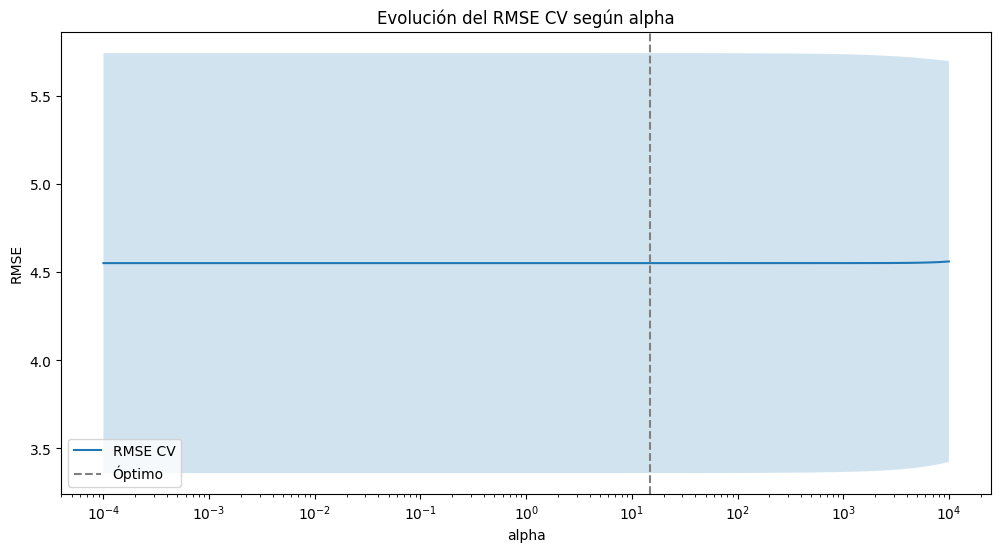

In [294]:
alphas = np.logspace(-4, 4, 100)
rmse_mean = []
rmse_std  = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for alpha in alphas:
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    
    # cross_val_score devuelve score (por defecto R^2), usamos scoring="neg_mean_squared_error"
    mse_scores = -cross_val_score(ridge, X_train_scaled, y_train,
                                  cv=kf,
                                  scoring="neg_mean_squared_error")
    
    rmse_mean.append(np.sqrt(mse_scores.mean()))
    rmse_std.append(np.sqrt(mse_scores.std()))

rmse_mean = np.array(rmse_mean)
rmse_std  = np.array(rmse_std)

# Alpha óptimo
optimo = alphas[np.argmin(rmse_mean)]

# Gráfico
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(alphas, rmse_mean, label="RMSE CV")
ax.fill_between(alphas, rmse_mean - rmse_std, rmse_mean + rmse_std, alpha=0.2)
ax.axvline(optimo, linestyle="--", color="gray", label="Óptimo")
ax.set_xscale('log')
ax.set_xlabel("alpha")
ax.set_ylabel("RMSE")
ax.set_title("Evolución del RMSE CV según alpha")
ax.legend()
plt.show()

Se observa que el error se mantiene prácticamente estable a lo largo de todo el rango de alpha, con un valor óptimo alrededor de 10. Esto indica que el modelo no es muy sensible a la regularización en este caso.

In [295]:
print(f"Mejor valor de alpha encontrado: {modelo_ridge.alpha_}")

Mejor valor de alpha encontrado: 21.544346900318867


In [296]:
predicciones_ridge = modelo_ridge.predict(X = X_test_scaled)
predicciones_ridge = predicciones_ridge.flatten()
predicciones_ridge[:10]

array([ 7.16132015,  7.57977763,  9.40736033,  8.78431616, 13.15869143,
       17.12156618, 25.84876077,  7.32460558,  6.53690377, 13.12424376])

In [297]:
rmse_ridge = np.sqrt(mean_squared_error(y_test, predicciones_ridge))
print(f"El error (rmse) de test es: {rmse_ridge}")

El error (rmse) de test es: 5.296288009836877


In [298]:
import sklearn.metrics as metrics
R2 = metrics.r2_score(y_test, predicciones_ridge)
R2

0.7102291458403731

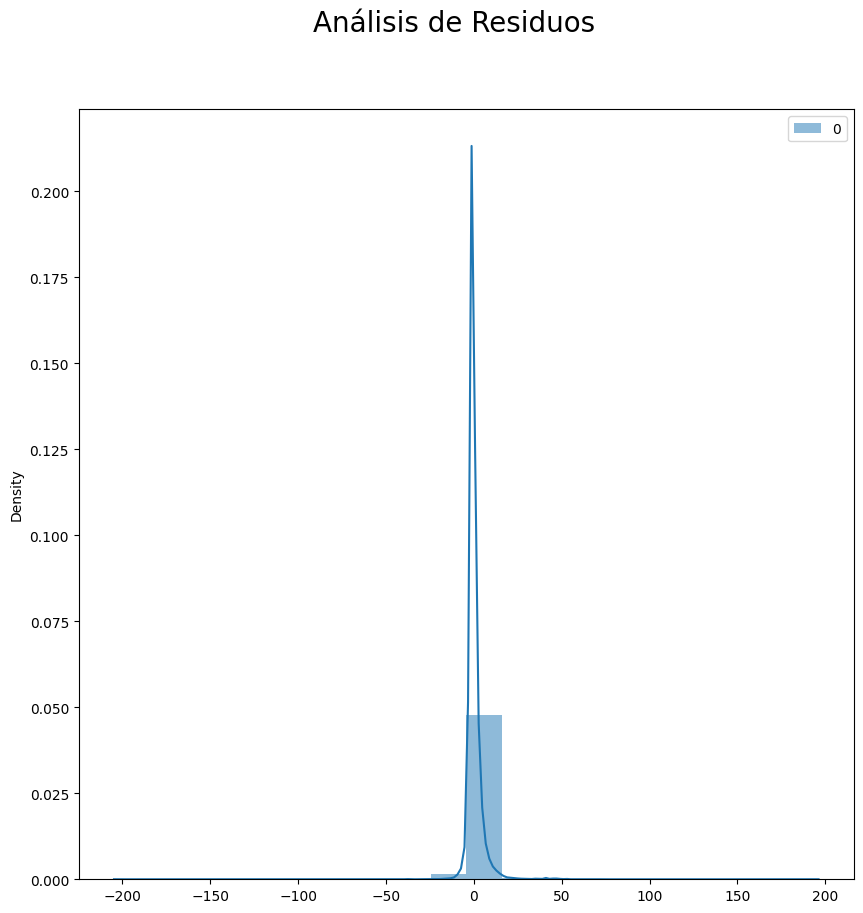

In [299]:
fig = plt.figure(figsize=(10,10))
  
sns.histplot((y_test - predicciones_ridge.reshape(y_test.shape)), color="red", kde=True, stat="density", linewidth=0,bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)    
plt.show()

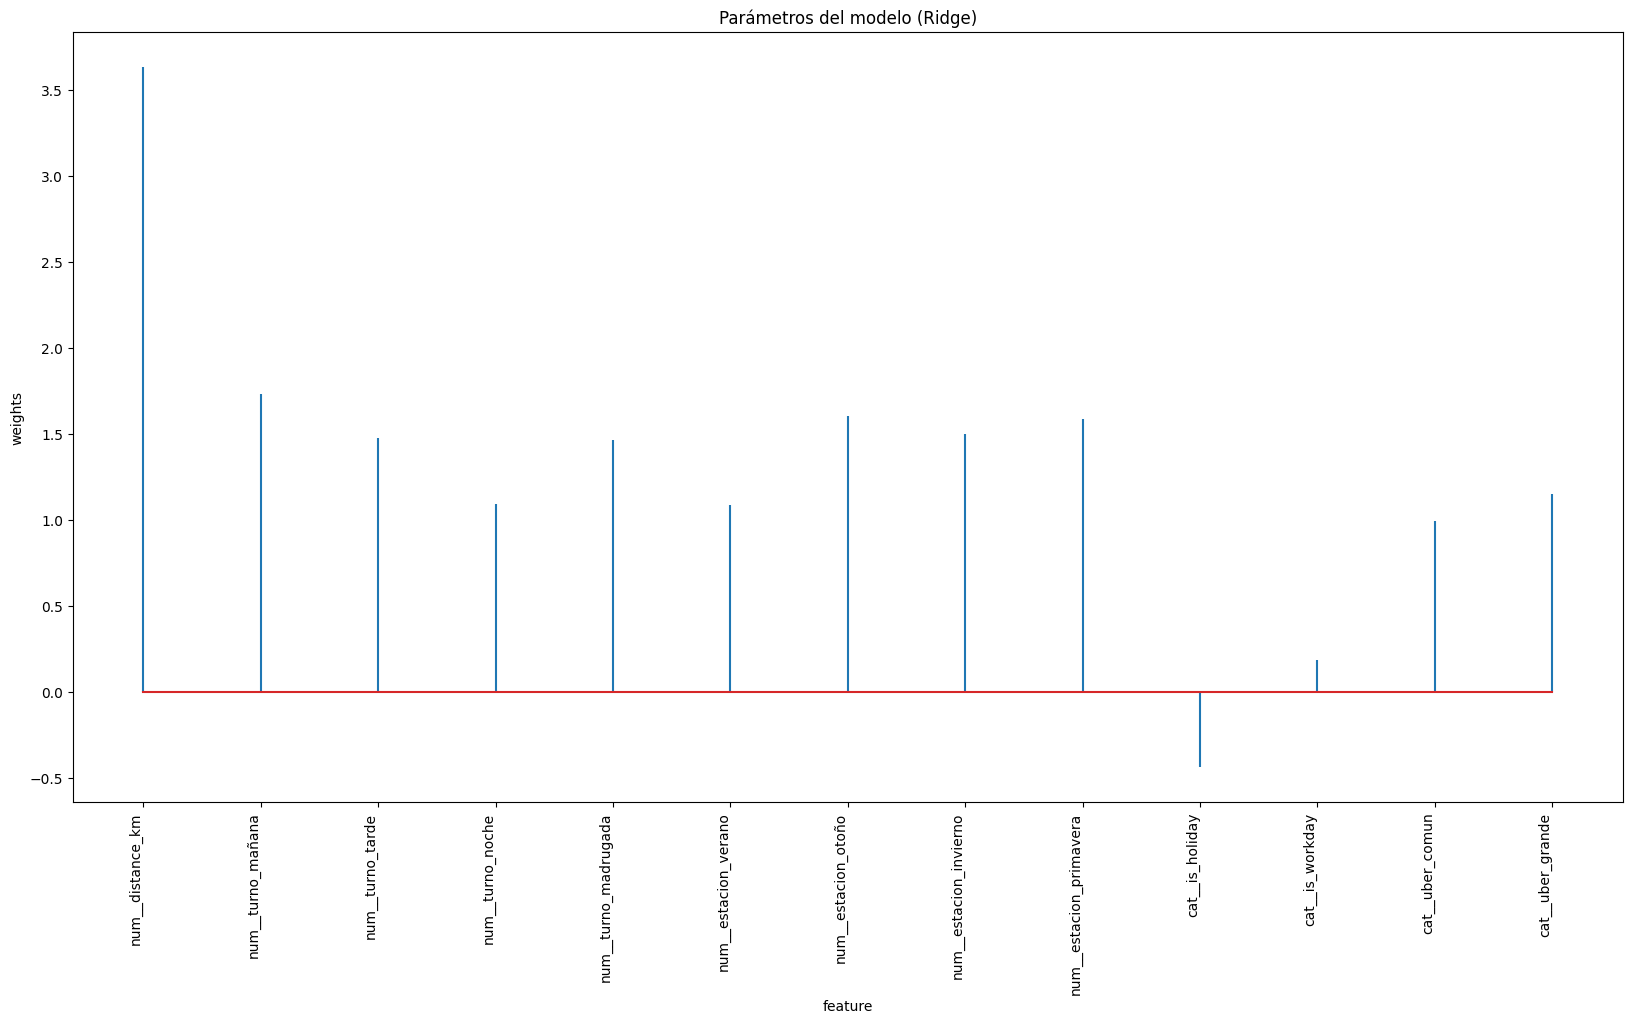

In [300]:
# Coeficientes del modelo Lasso
df_coeficientes = pd.DataFrame({
    "predictor": preprocessor.get_feature_names_out(),
    "coef": modelo_ridge.coef_.flatten()
})

# Gráfico
fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes["predictor"], df_coeficientes["coef"], markerfmt=" ")
plt.xticks(rotation=90, ha="right", size=10)
ax.set_xlabel("feature")
ax.set_ylabel("weights")
ax.set_title("Parámetros del modelo (Ridge)")
plt.show()

### _LASSO_

c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.462e+04, tolerance: 1.215e+03
  model = cd_fast.enet_coordinate_descent(


Mejor alpha encontrado: 0.0001


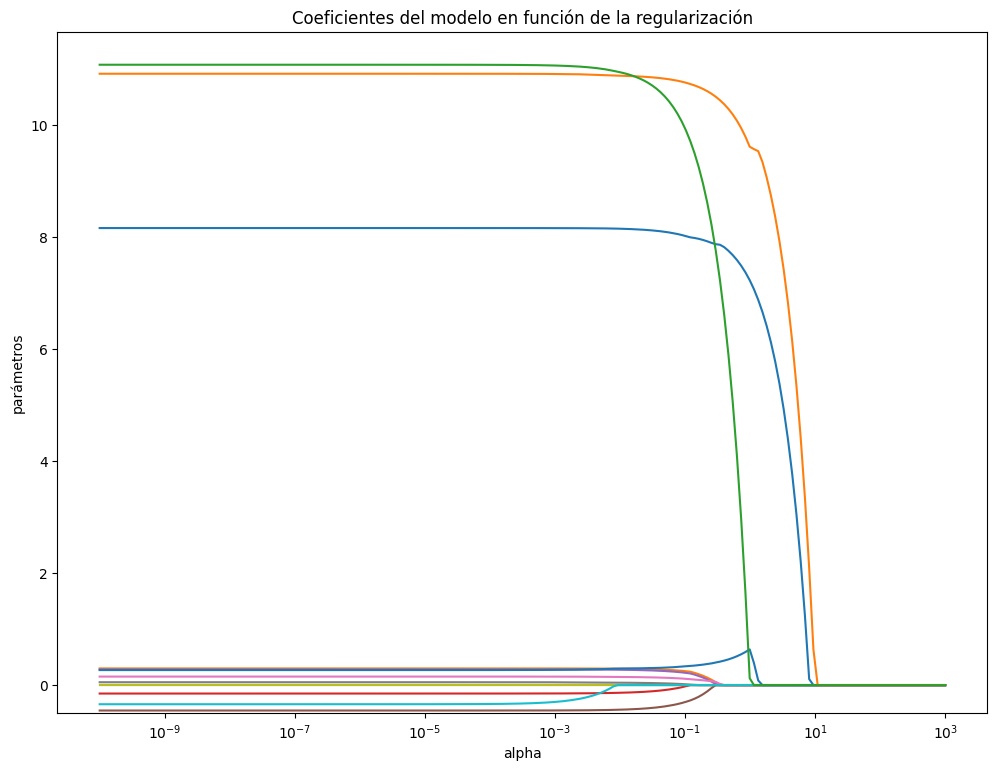

In [301]:
from sklearn.linear_model import lasso_path
modelo = LassoCV(alphas = np.logspace(-4, 4, 100), cv=10)
modelo.fit(X_train_scaled, y_train.flatten())           #TODAVIA ME FALTA REPASAR DONDE VA X_VAL_SCALED
print("Mejor alpha encontrado:", modelo.alpha_)

# Usar lasso_path para obtener coeficientes en un rango de alphas
alphas_lasso, coefs_lasso, _ = lasso_path(X_train_scaled, y_train.flatten(), alphas=np.logspace(-10, 3, 200))

# Graficar
fig, ax = plt.subplots(figsize=(12, 8.84))
ax.plot(alphas_lasso, coefs_lasso.T)   # transponer para graficar cada coef
ax.set_xscale('log')
ax.set_ylim([-0.5, None])
ax.set_xlabel('alpha')
ax.set_ylabel('parámetros')
ax.set_title('Coeficientes del modelo en función de la regularización')
plt.show()




Cuando alpha es muy bajo, los coeficientes se mantienen altos y sin cambios. A medida que aumenta la regularización, los parámetros comienzan a reducirse de forma drástica, llegando incluso a valores cercanos a cero. Esto muestra cómo la regularización controla el peso de las variables, forzando al modelo a simplificarse y depender menos de ciertos predictores. Con valores bajos del parámetro conserva todas las variables y se acerca también a la regresión lineal simple.

c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.534e+04, tolerance: 2.895e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.530e+04, tolerance: 2.895e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

Text(0.5, 1.0, 'Features incluidas en función de la regularización')

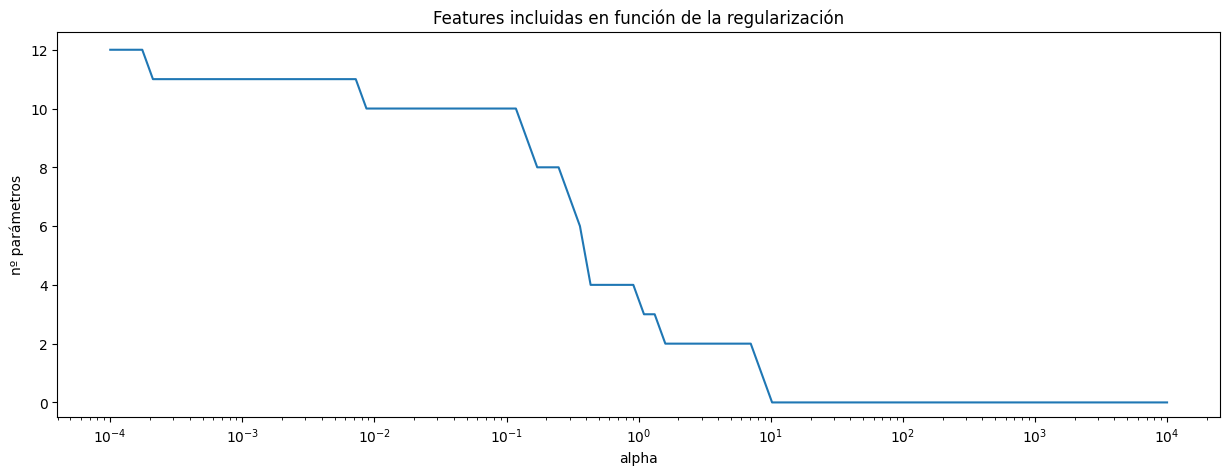

In [302]:

alphas = modelo.alphas_
n_predictores = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train_scaled, y_train)
    coef_no_cero = np.sum(modelo_temp.coef_.flatten() != 0)
    n_predictores.append(coef_no_cero)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_ylim([-0.5,None])
ax.set_xlabel('alpha')
ax.set_ylabel('nº parámetros')
ax.set_title('Features incluidas en función de la regularización')


El gráfico muestra cómo, al aumentar alpha, el modelo va reduciendo progresivamente la cantidad de variables utilizadas. Para valores bajos de regularización se incluyen casi todas las variables, mientras que a medida que la penalización crece, muchos coeficientes son forzados a cero y las variables dejan de participar en el modelo.

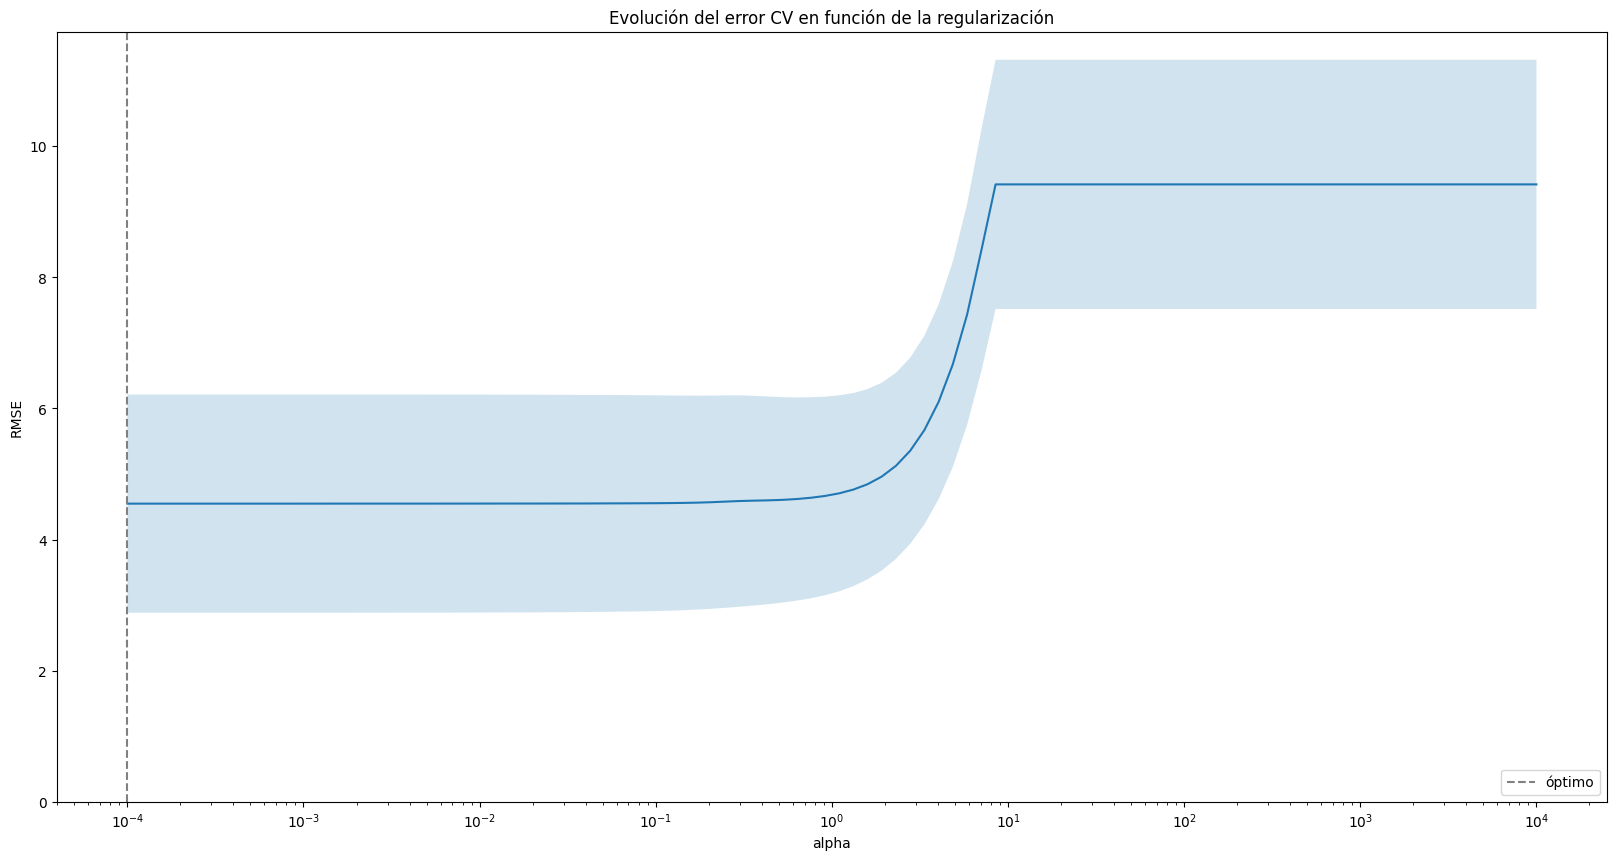

In [303]:
# Evolución del error de validación cruzada en función de alpha

mse_cv = modelo.mse_path_.mean(axis=1)
mse_sd = modelo.mse_path_.std(axis=1)

# Se aplica la raíz cuadrada para pasar de mse a rmse
rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Se identifica el óptimo y el óptimo + 1std
min_rmse     = np.min(rmse_cv)
optimo       = modelo.alphas_[np.argmin(rmse_cv)]

# Gráfico del error +- 1 desviación estándar
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(modelo.alphas_, rmse_cv)
ax.fill_between(
    modelo.alphas_,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)

ax.axvline(
    x         = optimo,
    c         = "gray",
    linestyle = '--',
    label     = 'óptimo'
)

ax.set_xscale('log')
ax.set_ylim([0,None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()

Se observa que el error se mantiene bajo y estable para valores pequeños de alpha, mientras que a medida que la regularización aumenta demasiado, el error crece de forma marcada. El valor óptimo se encuentra en un alpha muy bajo, lo que indica que el modelo necesita poca penalización para lograr un buen ajuste y que una regularización excesiva afecta negativamente su desempeño.

In [304]:
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")

Mejor valor de alpha encontrado: 0.0001


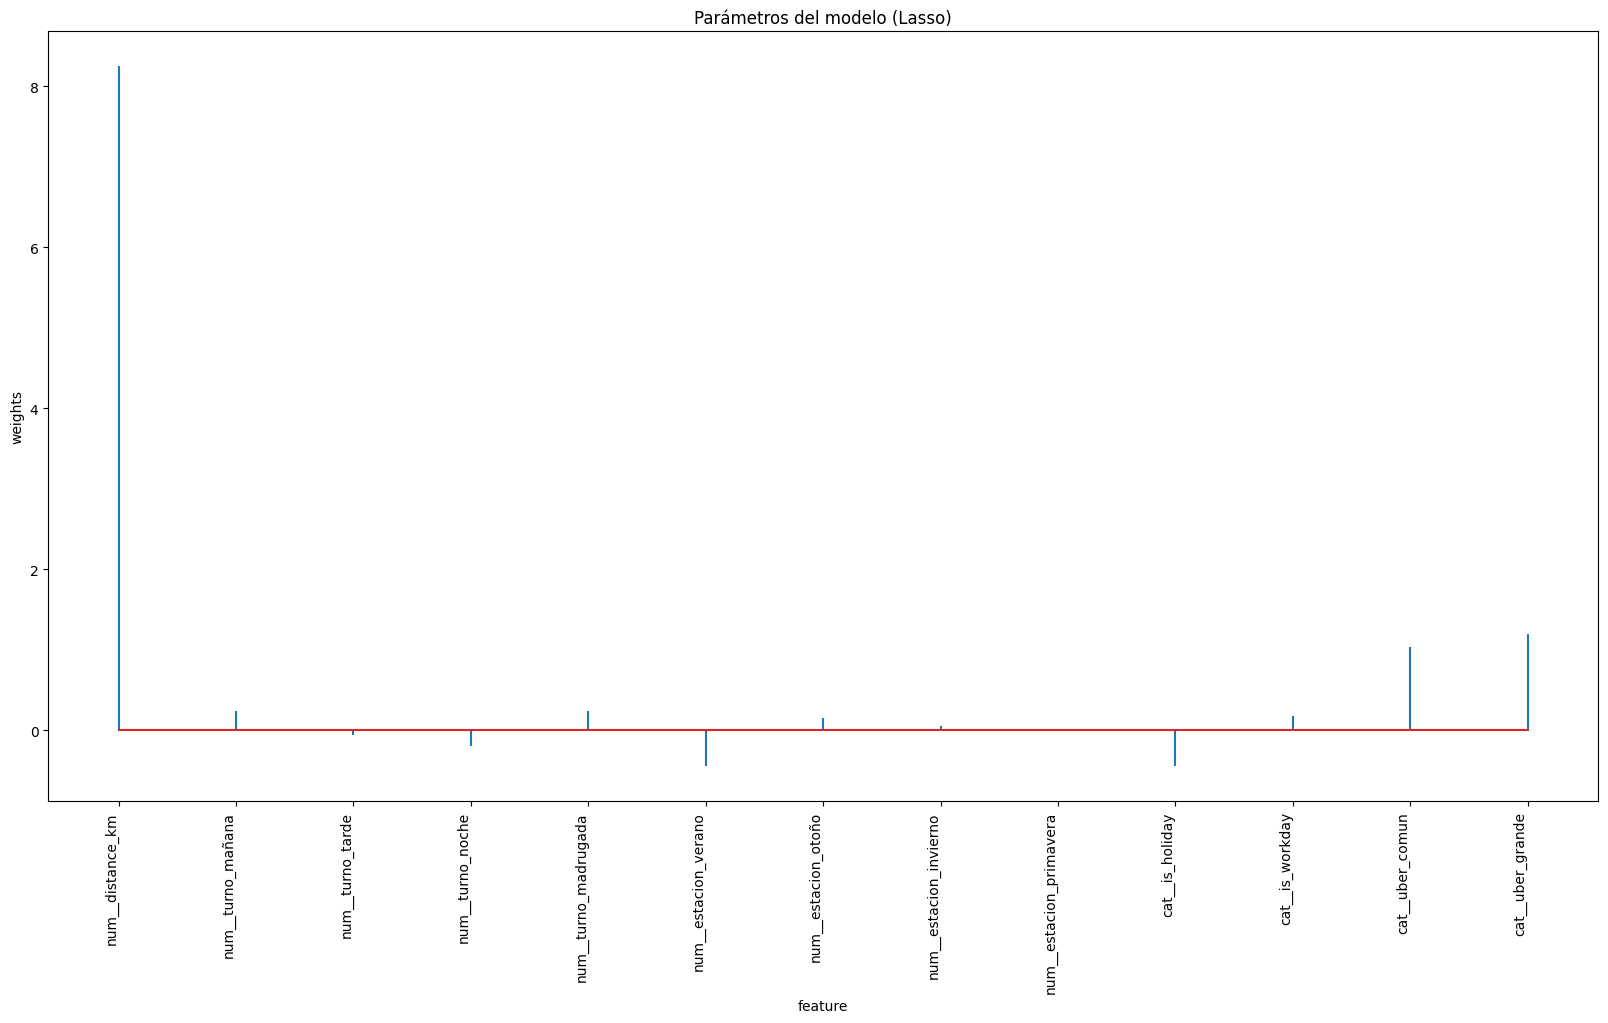

In [305]:
# Coeficientes del modelo Lasso
df_coeficientes = pd.DataFrame({
    "predictor": preprocessor.get_feature_names_out(),
    "coef": modelo.coef_.flatten()
})

# Gráfico
fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes["predictor"], df_coeficientes["coef"], markerfmt=" ")
plt.xticks(rotation=90, ha="right", size=10)
ax.set_xlabel("feature")
ax.set_ylabel("weights")
ax.set_title("Parámetros del modelo (Lasso)")
plt.show()

Se observa que la variable distance_km sigue siendo la más influyente en la predicción, mientras que varias de las variables dummies tienen coeficientes muy cercanos a cero o directamente fueron reducidas por la regularización. Esto refleja cómo Lasso selecciona solo las variables más relevantes, descartando automáticamente aquellas con menor poder explicativo.

In [306]:
predicciones_lasso = modelo.predict(X=X_test_scaled) #Hacerlo con el x_val_scaled para ver el error en validación?
predicciones_lasso = predicciones_lasso.flatten()
predicciones_lasso[:10]

array([ 7.16109304,  7.57947331,  9.40816307,  8.78429043, 13.15901528,
       17.12187393, 25.84961961,  7.32460993,  6.53654394, 13.12447612])

In [307]:
rmse_lasso = np.sqrt(mean_squared_error(y_test, predicciones_lasso))
print(f"El error (rmse) de test es: {rmse_lasso}")

El error (rmse) de test es: 5.296265440218472


In [308]:
R2 = metrics.r2_score(y_test, predicciones_lasso)
R2

0.710231615495972

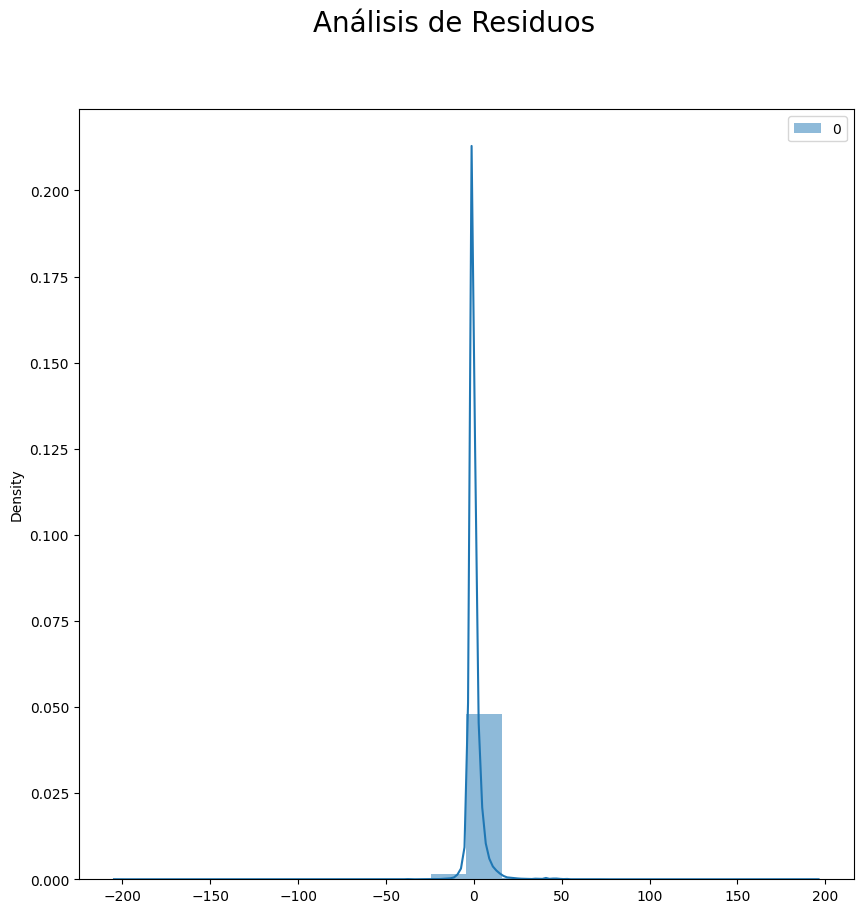

In [309]:
fig = plt.figure(figsize=(10,10))
  
sns.histplot((y_test - predicciones_lasso.reshape(y_test.shape)), color="red", kde=True, stat="density", linewidth=0,bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)    
plt.show()

### _ELASTIC NET_


In [310]:
modelo_elast = ElasticNetCV(
            l1_ratio        = [0.1, 0.5, 0.9], #Tuve que cambiar esto del original
            alphas          = np.logspace(-4, 2, 100), #Esto tambien
            cv              = 5,
            max_iter        = 10000
         )
_ = modelo_elast.fit(X = X_train_scaled, y = y_train.flatten())


c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.875e+05, tolerance: 1.215e+03
  model = cd_fast.enet_coordinate_descent(


In [311]:
# Predicciones con los mejores parámetros
pred = modelo_elast.predict(X_val_scaled)

# RMSE
rmse_elastic = np.sqrt(mean_squared_error(y_val, pred))
print("Alpha óptimo:", modelo_elast.alpha_)
print("L1_ratio óptimo:", modelo_elast.l1_ratio_)
print("RMSE en validación:", rmse)


Alpha óptimo: 0.0001747528400007683
L1_ratio óptimo: 0.1
RMSE en validación: 4.515177938913018


In [312]:
# Error medio de las 10 particiones por cada valor de alpha y l1_ratio 
mean_error_cv = modelo_elast.mse_path_.mean(axis =2)

# El resultado es un array de dimensiones (n_l1_ratio, n_alpha) se convierte en un dataframe
df_resultados_cv = pd.DataFrame(
                        data   = mean_error_cv.flatten(),
                        index  = pd.MultiIndex.from_product(
                                    iterables = [modelo_elast.l1_ratio, modelo_elast.alphas_],
                                    names     = ['l1_ratio', 'modelo.alphas_']
                                 ),
                        columns = ["mse_cv"]
                    )

df_resultados_cv['rmse_cv'] = np.sqrt(df_resultados_cv['mse_cv'])
df_resultados_cv = df_resultados_cv.reset_index().sort_values('mse_cv', ascending = True)
df_resultados_cv

,l1_ratio,modelo.alphas_,mse_cv,rmse_cv
95,0.1,0.000175,20.671021,4.546539
94,0.1,0.000201,20.671021,4.546539
96,0.1,0.000152,20.671022,4.546540
97,0.1,0.000132,20.671023,4.546540
93,0.1,0.000231,20.671023,4.546540
...,...,...,...,...
204,0.9,57.223677,88.663898,9.416151
205,0.9,49.770236,88.663898,9.416151
206,0.9,43.287613,88.663898,9.416151
101,0.5,86.974900,88.663898,9.416151


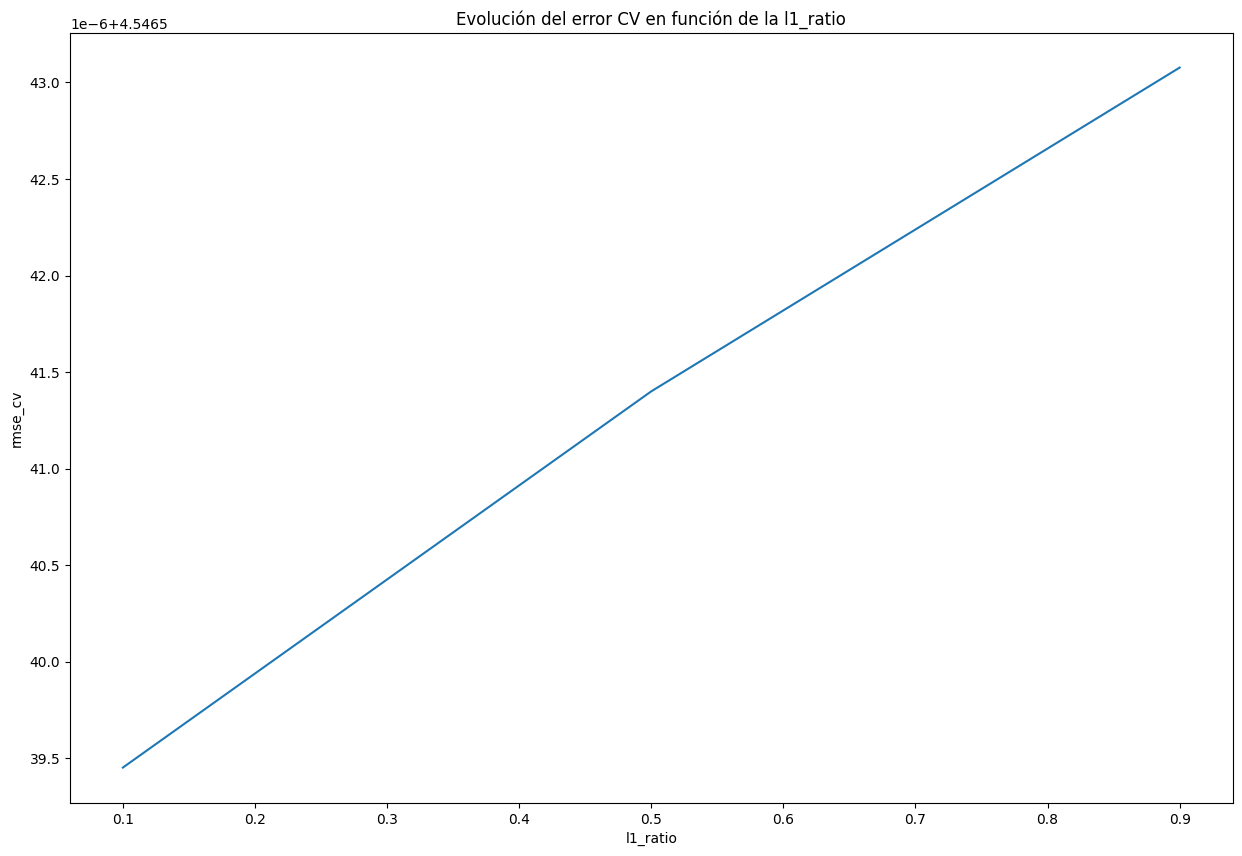

In [313]:
fig, ax = plt.subplots(figsize=(15, 10))
df_resultados_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax = ax)
ax.set_title('Evolución del error CV en función de la l1_ratio')
ax.set_xlabel('l1_ratio')
ax.set_ylabel('rmse_cv');

Se observa que, a medida que aumenta el valor de l1_ratio (es decir, se le da más peso a la penalización Lasso frente a Ridge), el error de validación también crece. Esto indica que en este caso la regularización tipo Ridge (valores de l1_ratio más cercanos a 0) resulta más adecuada que Lasso, ya que permite mantener un error más bajo y estable.

In [314]:
print("Mejor alpha:", modelo_elast.alpha_)
print("Mejor l1_ratio:", modelo_elast.l1_ratio_)

Mejor alpha: 0.0001747528400007683
Mejor l1_ratio: 0.1


In [315]:
pred_val = modelo_elast.predict(X_test_scaled)
pred_val = pred_val.flatten()

In [316]:
import sklearn.metrics as metrics
R2 = metrics.r2_score(y_test, pred_val)
R2

0.7102287866001766

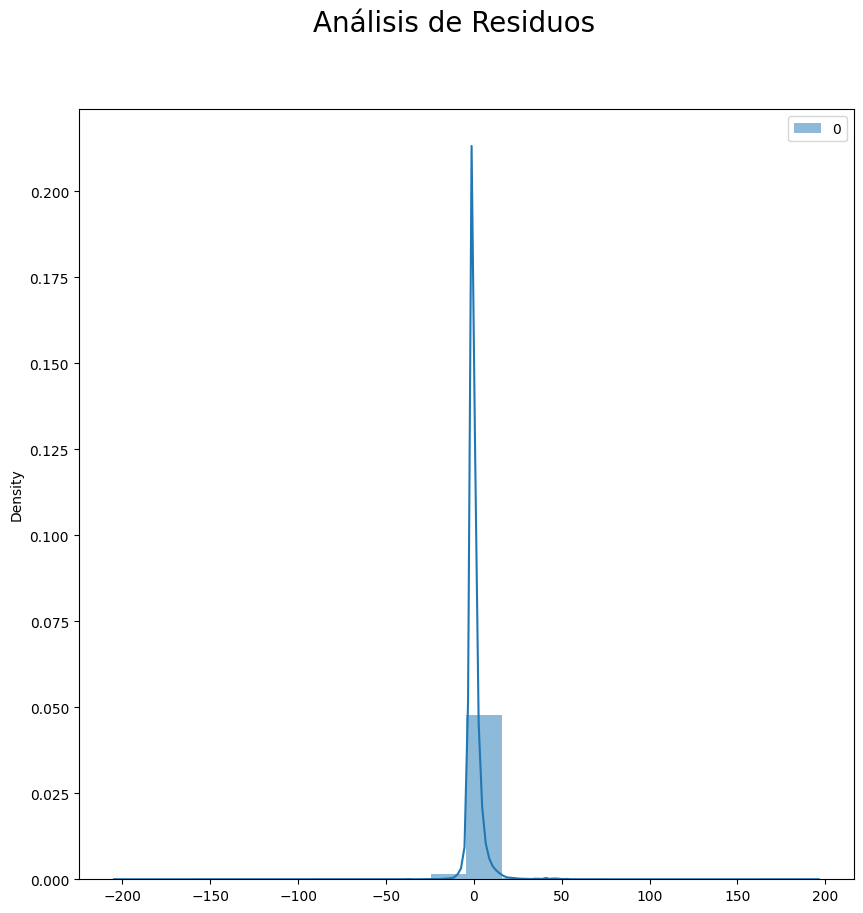

In [317]:
fig = plt.figure(figsize=(10,10))
  
sns.histplot((y_test - pred_val.reshape(y_test.shape)), color="red", kde=True, stat="density", linewidth=0,bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)    
plt.show()

### _Comparación de Modelos_

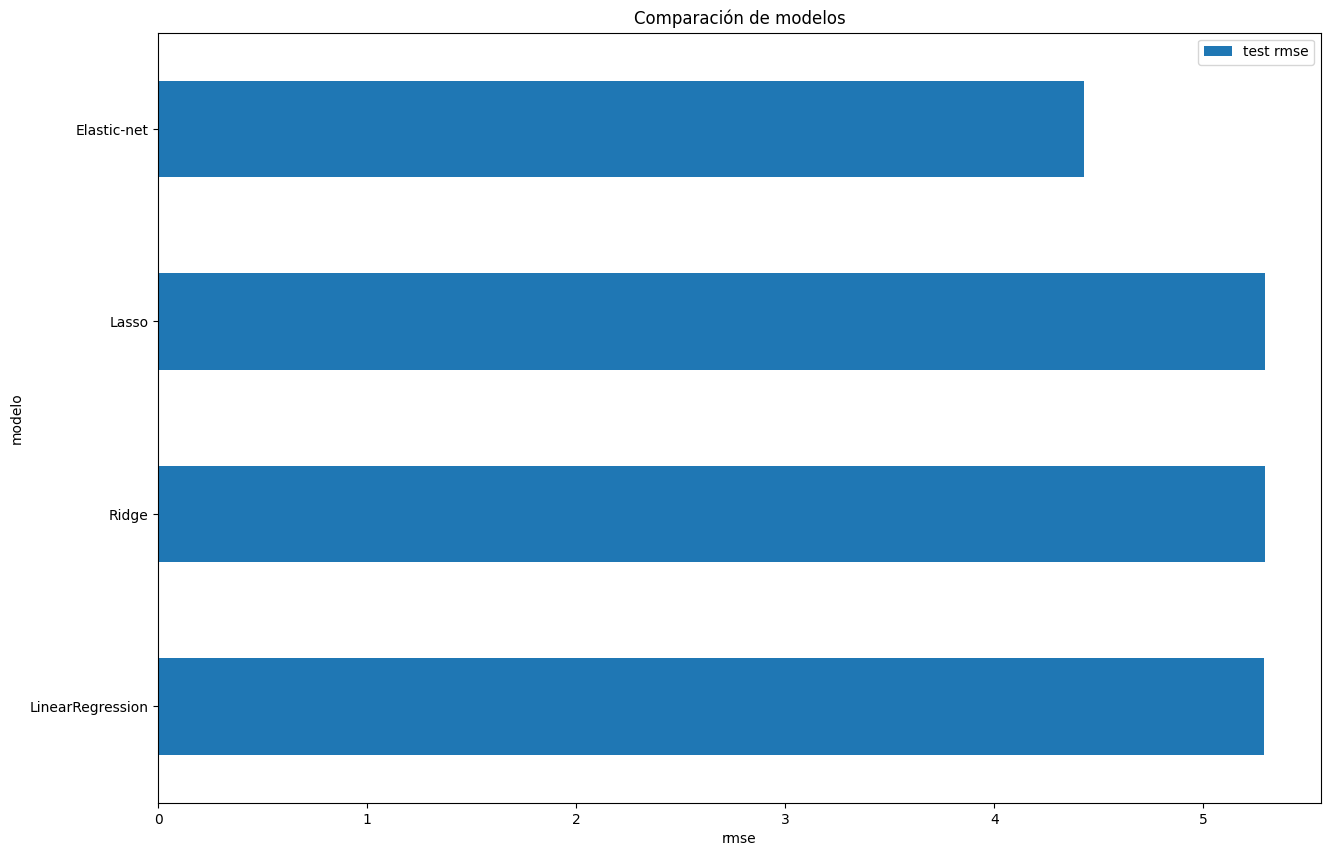

In [318]:
df_comparacion = pd.DataFrame({
                    'modelo': ['LinearRegression', 'Ridge', 'Lasso', 'Elastic-net'],
                    'test rmse': [rmse_ols, rmse_ridge, rmse_lasso, rmse_elastic]
                 })

fig, ax = plt.subplots(figsize=(15, 10))
df_comparacion.set_index('modelo').plot(kind='barh', ax=ax)
ax.set_xlabel('rmse')
ax.set_ylabel('modelo')
ax.set_title('Comparación de modelos');

Los resultados muestran que los modelos Ridge y Lasso obtienen un desempeño muy similar al de la regresión lineal simple, lo que indica que en este caso la regularización no produce una mejora significativa. Por otro lado, Elastic Net logra un RMSE ligeramente menor, aunque la diferencia no es muy marcada. En general, todos los modelos presentan un rendimiento comparable, lo que sugiere que la variable más determinante sigue siendo la distancia y que la regularización no cambia de forma sustancial el ajuste del modelo.

CONCLUSIÓN FINAL 
-----------------

### El análisis comparativo de modelos mostró que la regresión lineal, Ridge y Lasso alcanzaron resultados prácticamente idénticos (RMSE ≈ 5.29 y R² ≈ 0.71), lo que indica que la regularización no aportó mejoras significativas en este caso. Elastic Net logró reducir el error (RMSE ≈ 4.51), aunque mantuvo un R² similar, evidenciando un mejor balance entre simplicidad y ajuste del modelo.

### Por su parte, los métodos de optimización mediante gradiente descendente fueron los que alcanzaron el mejor desempeño general. El gradiente descendente por lotes (RMSE ≈ 4.43, R² ≈ 0.77) y el mini-batch (RMSE ≈ 4.44, R² ≈ 0.77) lograron los valores más bajos de error y la mayor capacidad de explicación de la variabilidad, mientras que el estocástico obtuvo resultados algo inferiores pero igualmente competitivos (RMSE ≈ 4.63, R² ≈ 0.75).

### En síntesis, se concluye que si bien los modelos lineales clásicos ofrecen una buena base y facilitan la interpretación, la aplicación de métodos iterativos de optimización —particularmente gradiente descendente y mini-batch— permitió obtener predicciones más precisas y un ajuste superior, constituyendo la alternativa más efectiva para este problema.